# **Lista 2 - Modelo de Previsão de Vendas**

Faça um projeto completo para a previsão de séries temporais da base de dados: HistoricoVendasPadaria.csv

Os seguintes passo devem estar implementados nesse projeto:

* Análise descritiva (decomposição)
* Separação de Treino e Teste
* Verificação de estacionaridade
* Trasformação e diferenciação se necessário - neste caso vamos dividir , vamos rodar 3 modelos para série trasformada(AR , MA e ARMA) e 3 modelos para série sem transformação (se for o caso) -> ARIMA / SARIMA e PROPHET
* Definição do Baseline (Modelo Naive) - observe a escolha ideal para o modelo estacionario e o modelo nao estacionario.
* Rodar modelos (sem Transformação)
* Rodar modelos (com transformação)
* Rodar o AutoArima
* Comaprar modelos com as Métricas de Erro: MAE, MSE, RMSE, MAPE, sMAPE e MASE. - interprete as métricas
* Selecionar o melhor modelo e gerar previsões

#**1. Introdução**
As séries temporais são utilizadas para analisar fenômenos observados ao longo do tempo, permitindo identificar padrões, tendências, comportamentos sazonais e relações de dependência entre observações consecutivas.

Neste projeto foi utilizada a base de vendas de padaria, que contém registros de venda, abrangendo aproximadamente o período de 2024 até 2025.

O objetivo é avaliar o comportamento temporal da série, verificar suas propriedades estatísticas e construir um modelo de previsão capaz de estimar valores futuros.

#**2. Contextualização do problema**

Os resultados de Venda de Padaria apresentam comportamento dinâmico e pode sofrer alterações ao longo do tempo em função de diferentes condições e eventos sazonais.

Nesse contexto, surge a seguinte questão:

É possível utilizar um modelo de séries temporais para representar adequadamente o comportamento histórico da padaria e realizar previsões de seus valores futuros?

Para responder a essa questão serão realizadas as seguintes etapas:

* Tratamento e organização dos dados;
* Análise exploratória;
* Identificação de possíveis outliers;
* Investigação de possíveis quebras estruturais;
* Decomposição da série;
* Análise de autocorrelação;
* Verificação da estacionaridade;
* Avaliação da normalidade;
* Estimação de diferentes modelos ARIMA;
* Comparação dos modelos;
* Diagnóstico dos resíduos;
* Avaliação da capacidade preditiva.

#**3. Carregamento da Base**

In [1450]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts

#!pip install prophet
from prophet import Prophet

#!pip install pmdarima
from pmdarima import auto_arima

from statsmodels.tsa.ar_model import AutoReg
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/HistoricoVendasPadaria.csv")
df.head()

,Data,Vendas
0,2024-02-04,52
1,2024-02-05,20
2,2024-02-06,34
3,2024-02-07,31
4,2024-02-08,36


In [1451]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    364 non-null    object
 1   Vendas  364 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.8+ KB


#**4. Tratamento e preparação dos dados**

In [1452]:
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data")
df.set_index("Data", inplace=True)
df.head()

,Vendas
Data,
2024-02-04,52
2024-02-05,20
2024-02-06,34
2024-02-07,31
2024-02-08,36


### **4.1 Verificação de Valores da Dataframe**

In [1453]:
df.shape

(364, 1)

In [1454]:
df.isna().sum()

,0
Vendas,0


In [1455]:
df.index.duplicated().sum()

np.int64(0)

# **5. Seleção da série para análise**

In [1456]:
serie = df.copy()

#**6. Análise Descritiva**

A assimetria positiva (0,899635) indica uma **assimetria moderada à direita na distribuição das vendas, sugerindo que há uma concentração maior de observações em valores mais baixos**, enquanto alguns valores mais elevados contribuem para o **alongamento da cauda direita**. A curtose positiva (0,078120) **indica uma distribuição ligeiramente leptocúrtica, com concentração e comportamento das caudas muito próximos aos observados em uma distribuição normal**.

A média das vendas foi de 45,310440, enquanto a mediana foi de 41,000000, evidenciando uma **diferença entre essas duas medidas de tendência central**. A média superior à mediana é consistente com a assimetria positiva observada, indicando que os valores mais elevados de vendas exercem influência sobre a média.

In [1457]:
serie.describe()

,Vendas
count,364.000000
mean,45.310440
std,16.308317
min,20.000000
25%,32.000000
50%,41.000000
75%,54.000000
max,95.000000


In [1458]:
df["Vendas"].skew() #assimetria

np.float64(0.899635201075047)

In [1459]:
df["Vendas"].kurt() #curtose

np.float64(0.07812036522969645)

#**7. Outliers**

A análise dos outliers será realizada considerando os limites definidos pelo método IQR. Os valores identificados como extremos **não serão automaticamente removidos, pois, em uma série financeira/econômica, valores extremos podem representar mudanças reais** e **não necessariamente erros de coleta**.

Caso os valores identificados sejam mantidos, essa decisão deverá ser justificada pelo fato de que a **remoção indiscriminada poderia eliminar informações relevantes da dinâmica temporal**.

In [1460]:
Q1 = serie.quantile(0.25)
Q3 = serie.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = serie[
    (serie["Vendas"] < limite_inferior["Vendas"])
    | (serie["Vendas"] > limite_superior["Vendas"])
]
print("Quantidade de outliers:", len(outliers))

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Quantidade de outliers:", len(outliers))

Quantidade de outliers: 4
Q1: Vendas    32.0
Name: 0.25, dtype: float64
Q3: Vendas    54.0
Name: 0.75, dtype: float64
IQR: Vendas    22.0
dtype: float64
Limite inferior: Vendas   -1.0
dtype: float64
Limite superior: Vendas    87.0
dtype: float64
Quantidade de outliers: 4


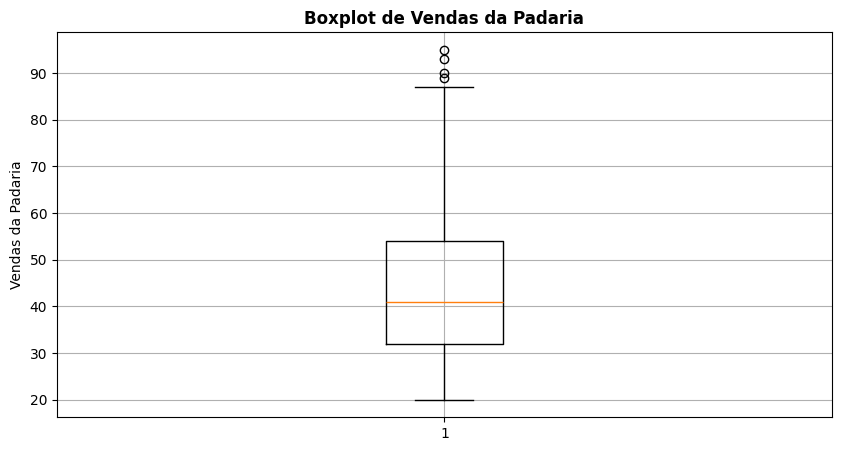

In [1461]:
plt.figure(figsize=(10, 5))
plt.boxplot(serie)
plt.title("Boxplot de Vendas da Padaria", fontweight='bold')
plt.ylabel("Vendas da Padaria")
plt.grid(True)
plt.show()

#**8. Quebras Estruturais**
Comportamento da série ao longo do período.

Uma forma inicial de investigação consiste em comparar médias móveis e estatísticas entre diferentes períodos.

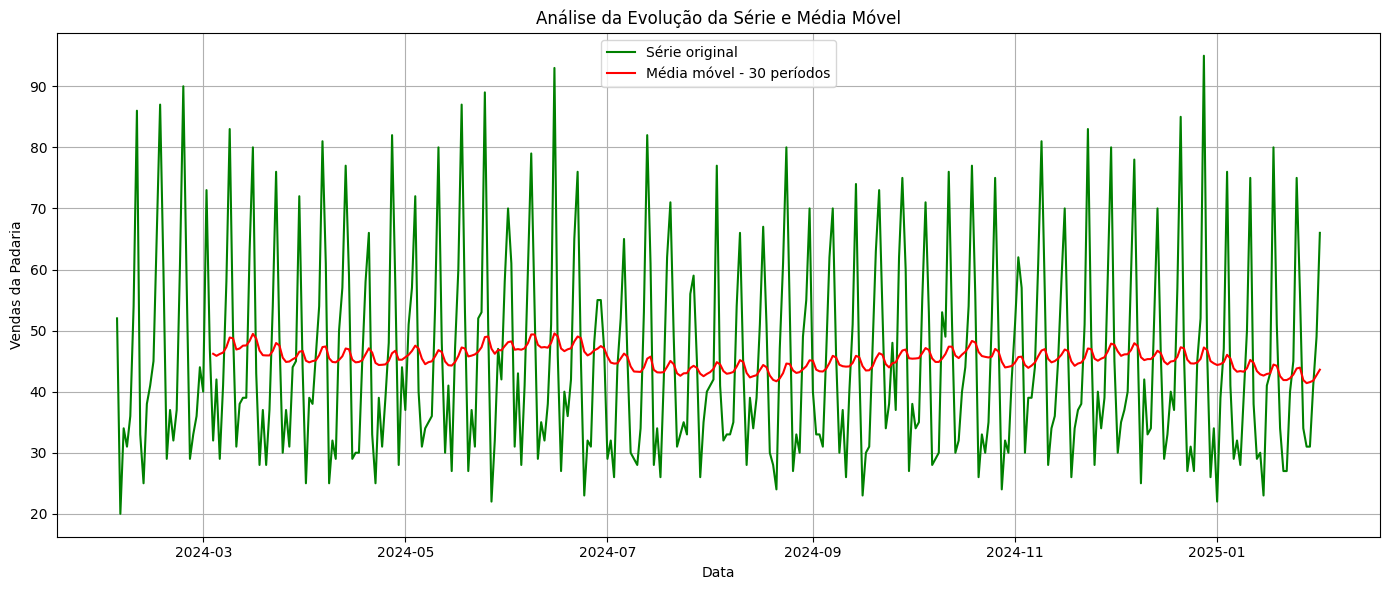

In [1462]:
media_movel = serie.rolling(window=30).mean()
desvio_movel = serie.rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(serie, label="Série original", color="green")
plt.plot(media_movel, label="Média móvel - 30 períodos", color="red")
plt.title("Análise da Evolução da Série e Média Móvel")
plt.xlabel("Data")
plt.ylabel("Vendas da Padaria")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **9. Visualização da série temporal**

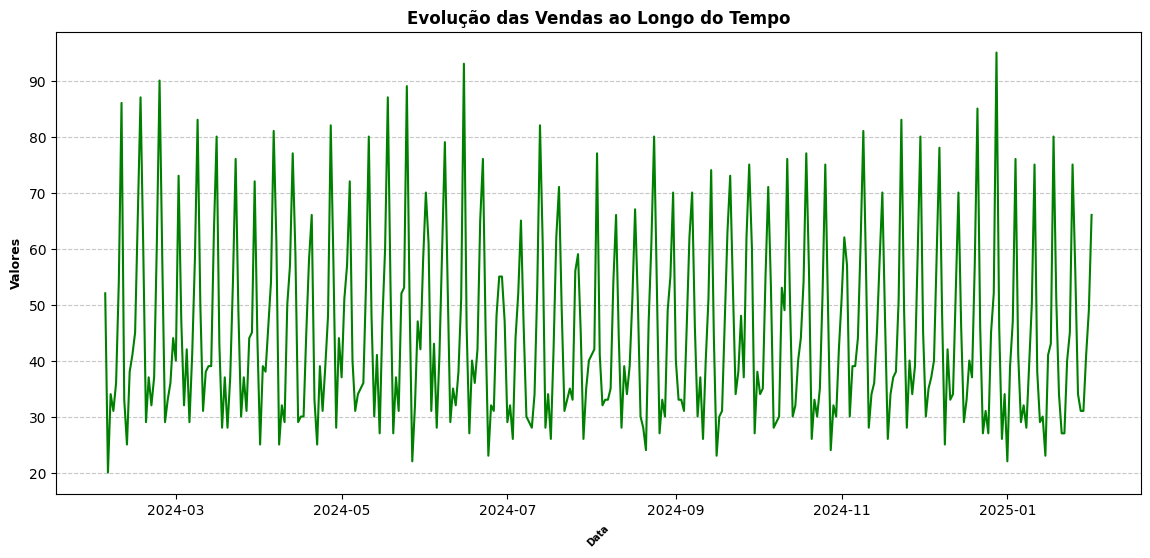

In [1463]:
plt.figure(figsize=(14, 6))
plt.plot(serie, color="green")
plt.title("Evolução das Vendas ao Longo do Tempo", fontweight='bold')
plt.xlabel("Data", fontweight='bold', rotation=45, fontsize=7)
plt.ylabel("Valores", fontweight='bold', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **10. Decomposição das Variáveis da Série Original**

A decomposição permite separar a série em componentes de:

* Tendência;
* Sazonalidade;
* Resíduos.

Como a base possui observações diárias, será considerada inicialmente uma periodicidade de 7 observações, representando um possível padrão semanal.

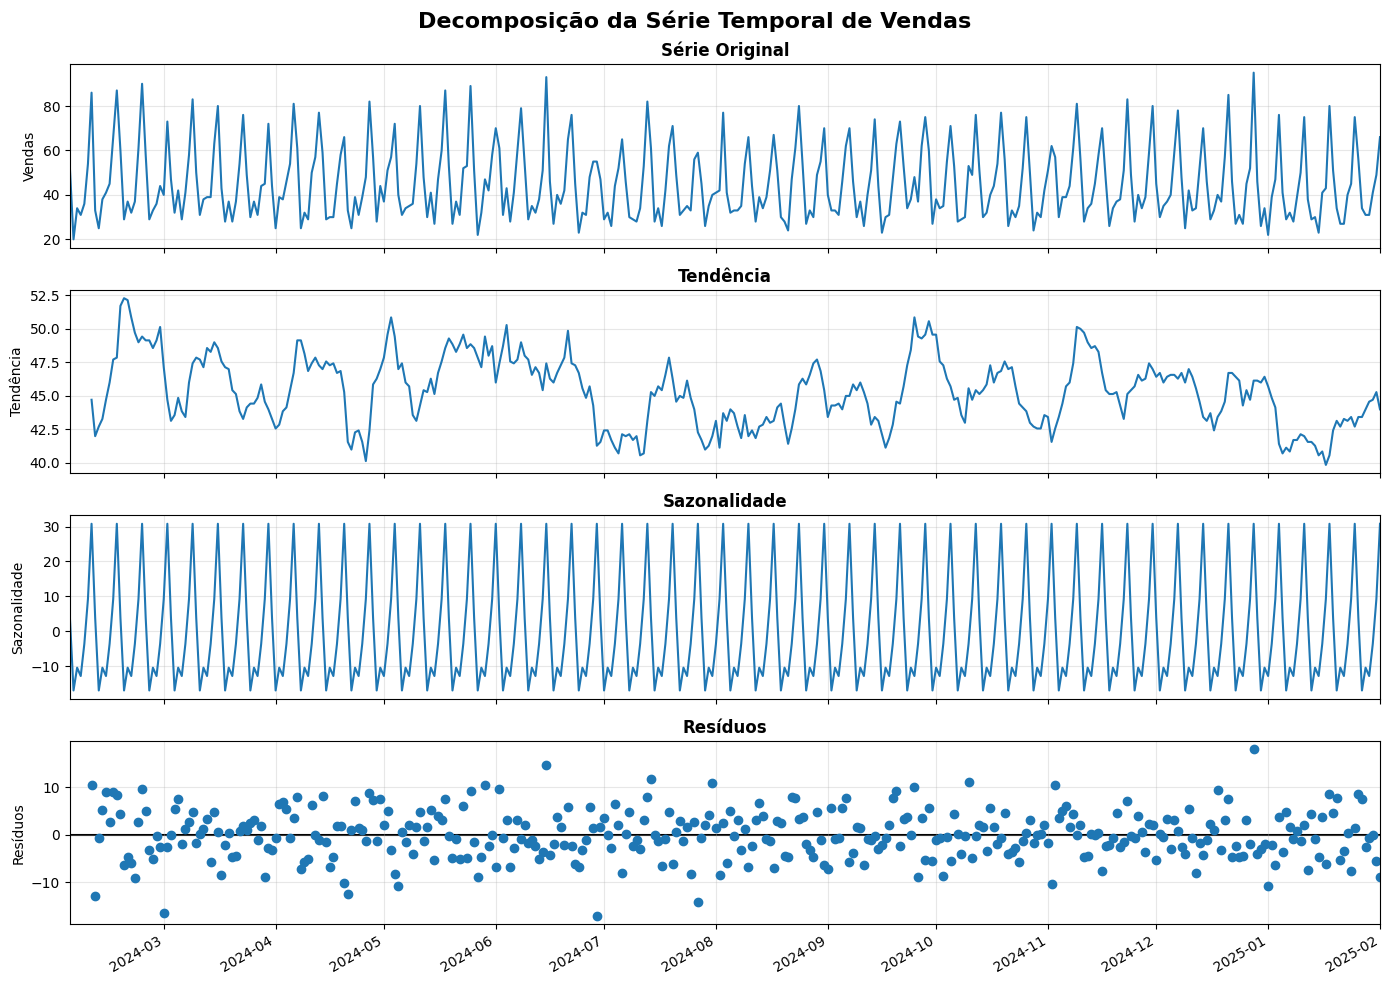

In [1464]:
# Decomposição da série temporal
decomposicao = seasonal_decompose(
    df["Vendas"],
    model="additive",
    period=7,
    two_sided=False
)

# Criando a figura com tamanho maior
fig = decomposicao.plot()

# Ajustando o tamanho da figura
fig.set_size_inches(14, 10)
fig.suptitle(
    "Decomposição da Série Temporal de Vendas",
    fontsize=16,
    fontweight="bold"
)

titulos = ["Série Original", "Tendência", "Sazonalidade", "Resíduos"]
rotulos = ["Vendas", "Tendência", "Sazonalidade", "Resíduos"]

for ax, titulo, rotulo in zip(fig.axes, titulos, rotulos):
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_ylabel(rotulo)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

A decomposição permite avaliar separadamente o comportamento da tendência, da sazonalidade e dos resíduos.

A escolha de period=7 foi utilizada para investigar uma possível periodicidade semanal. E nessa visualização, **foi encontrado a existência de sazonalidade significativa que deve ser avaliada por meio das demais análises da série**.

**Conclusão da decomposição**: **A decomposição aditiva da série temporal evidencia a existência de uma forte sazonalidade semanal**, representada por um **padrão que se repete aproximadamente a cada 7 períodos**. A componente de tendência apresenta oscilações ao longo do tempo, sem indicar um crescimento ou declínio contínuo da série. Os resíduos permanecem, em sua maioria, próximos de zero, embora sejam observados alguns valores extremos. Dessa forma, conclui-se que a sazonalidade semanal é um dos principais componentes responsáveis pelas variações nas vendas. Esse resultado é relevante para a etapa de modelagem, indicando que modelos capazes de representar efeitos sazonais, como o SARIMA e o AutoARIMA com sazonalidade, podem ser particularmente adequados para a previsão da série





# **11. Análise de Autocorrelação da Série Original**
A autocorrelação permite verificar a relação entre uma observação e seus valores anteriores.

## **11.1 ACF (Autocorrelation Function)**
Mostra a correlação da série com seus próprios valores anteriores (lags).

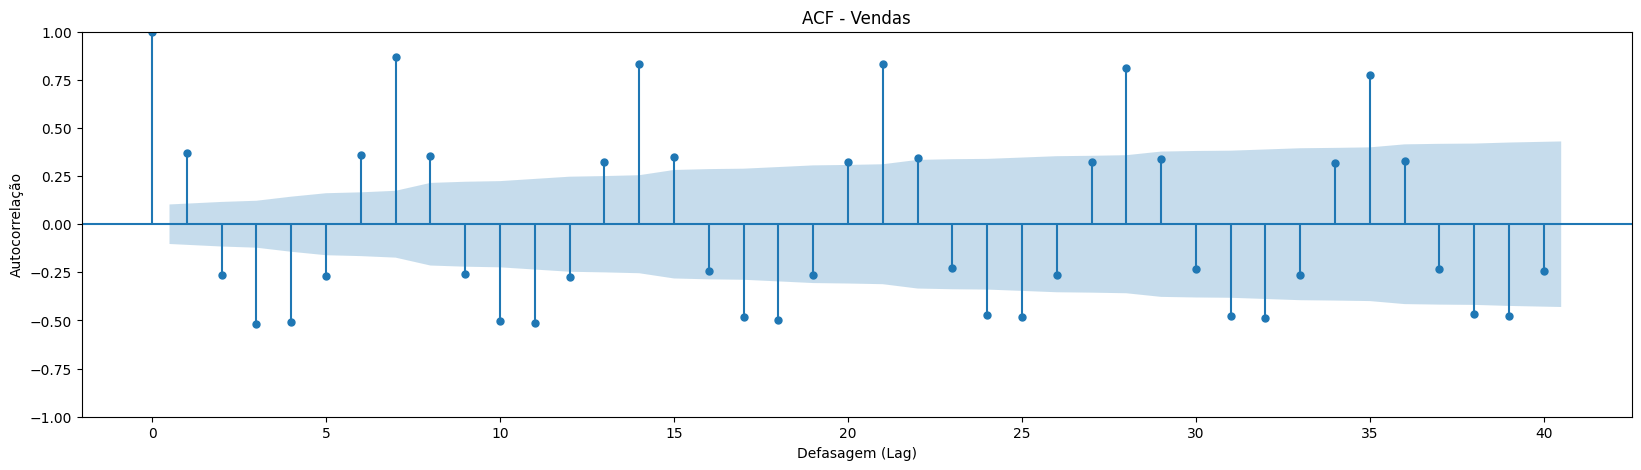

In [1465]:
serie = df["Vendas"].dropna()

plt.figure(figsize=(20, 5))
plot_acf(serie, lags=40, ax=plt.gca())
plt.title("ACF - Vendas")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação")
plt.show()

## **11.2 PACF (Partial Autocorrelation Function)**
Mostra a correlação entre a série e seus valores anteriores, eliminando o efeito dos lags intermediários.

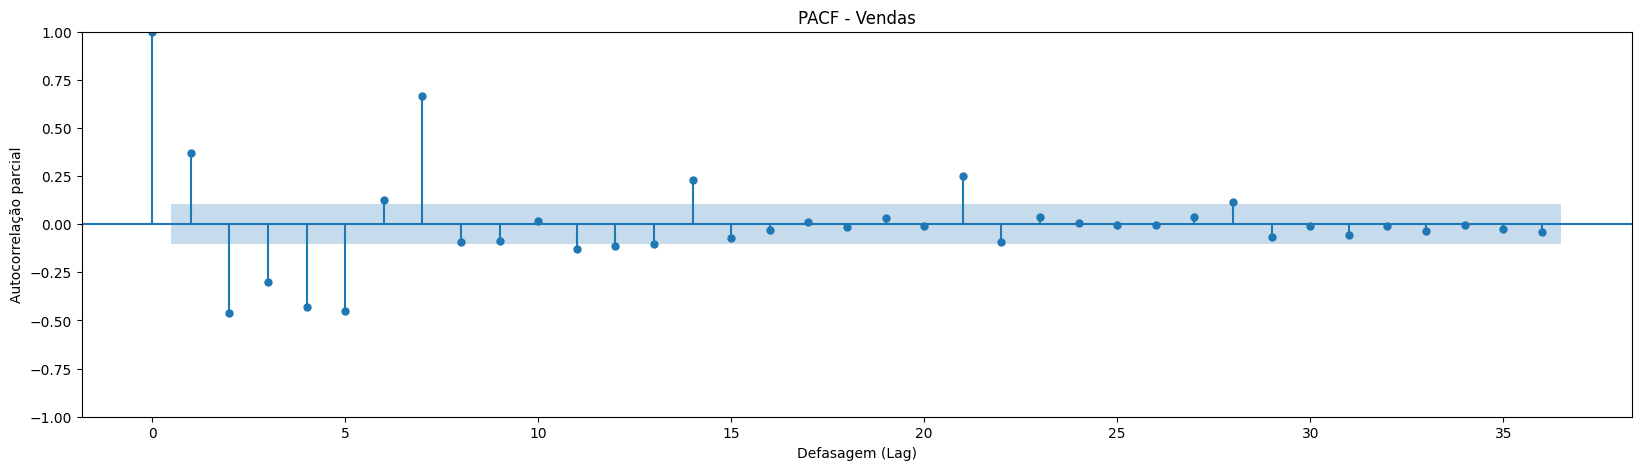

In [1466]:
plt.figure(figsize=(20, 5))
plot_pacf(serie, lags=36, ax=plt.gca(), method="ywm")

plt.title("PACF - Vendas")
plt.xlabel("Defasagem (Lag)")
plt.ylabel("Autocorrelação parcial")
plt.show()

## **11.3 Conclusão da Análise**
A análise da **ACF revelou autocorrelações significativas** em diversos lags, com um **padrão oscilatório e picos positivos** aproximadamente nos lags 7, 14, 21, 28 e 35, indicando **forte dependência temporal e possível sazonalidade de 7 períodos**. Esse comportamento também sugere que a série pode não ser estacionária.

Na **PACF, observa-se uma forte correlação no primeiro lag**, além de valores significativos até aproximadamente o lag 7, com destaque para esse período. Esse **padrão indica a possível presença de componentes autorregressivos**, tanto de **curto prazo quanto associados à sazonalidade de 7 períodos**, informação importante para a escolha do modelo de séries temporais.

#**12. Verificação de Estacionaridade da Série Original**

A estacionaridade é uma propriedade importante para a modelagem ARIMA.

##**12.1 ADF**

In [1467]:
# Teste de ADF
resultado_adf = adfuller(serie)

print("Teste ADF")
print("Estatística:", resultado_adf[0])
print("P-valor:", resultado_adf[1])

if resultado_adf[1] < 0.05:
    print("Resultado: A série é ESTACIONÁRIA.")
else:
    print("Resultado: A série NÃO é ESTACIONÁRIA.")

Teste ADF
Estatística: -4.151412985105574
P-valor: 0.000795423837204794
Resultado: A série é ESTACIONÁRIA.


##**12.2 KPSS**

In [1468]:
# Teste de KPSS
resultado_kpss = kpss(
    serie,
    regression="c",
    nlags="auto"
)

print("\nTeste KPSS")
print("Estatística:", resultado_kpss[0])
print("P-valor:", resultado_kpss[1])

if resultado_kpss[1] < 0.05:
    print("Resultado: A série NÃO é estacionária.\n")
else:
    print("Resultado: A série é ESTACIONÁRIA.\n")


Teste KPSS
Estatística: 0.1953913119919465
P-valor: 0.1
Resultado: A série é ESTACIONÁRIA.



/tmp/ipykernel_5909/2219790916.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado_kpss = kpss(


## **12.3 Conclusão**
Os testes ADF e KPSS indicam que a série de vendas é estacionária. O teste KPSS apresentou p-valor de 0,10, enquanto o ADF apresentou p-valor de 0,0008. Dessa forma, ambos os resultados confirmam a estacionaridade da série, não sendo necessária a aplicação de diferenciação. Portanto, a série poderá ser utilizada em seu formato original na etapa de modelagem.

# **13. Análise de Normalidade**
A normalidade da série original também foi investigada por meio do teste de Jarque-Bera.

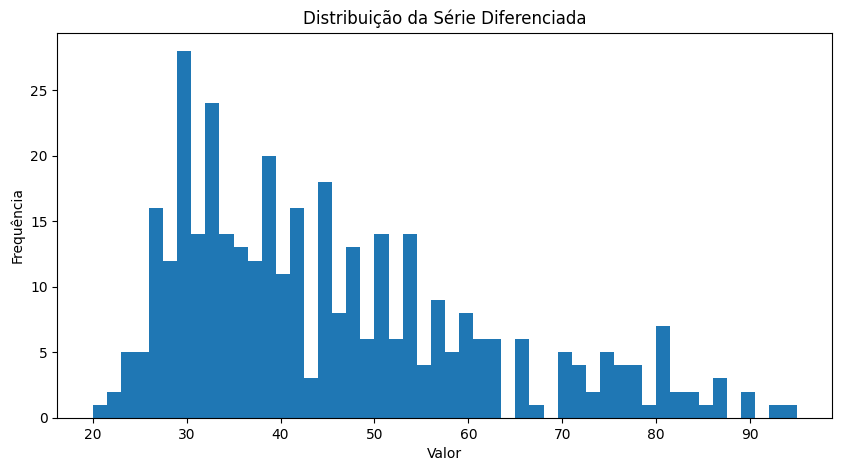

In [1469]:
plt.figure(figsize=(10,5))
plt.hist(serie, bins=50)
plt.title("Distribuição da Série Diferenciada")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

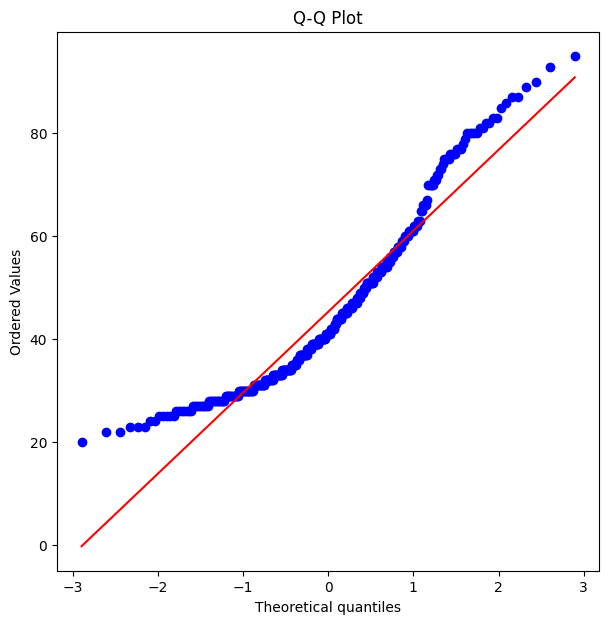

In [1470]:
plt.figure(figsize=(7,7))
stats.probplot(serie, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [1471]:
jb_stat, p_value = jarque_bera(serie)

print("Estatística Jarque-Bera:", jb_stat)
print("P-valor:", p_value)

if p_value < 0.05:
    conclusao = "Rejeita-se H0. A série não apresenta distribuição normal."
else:
    conclusao = "Não se rejeita H0. Não há evidências suficientes contra a normalidade."

print(conclusao)

Estatística Jarque-Bera: 48.75159332698568
P-valor: 2.5925432907563457e-11
Rejeita-se H0. A série não apresenta distribuição normal.


##**13.1 Normalização dos Dados**
Mesmo aplicando a normalização os resultados, não foram suficientes para que tornasem os dados em uma distribuição normal. Foi aplicado o pacote de pre-processamento dos dados para isso. Todavia, mesmo aplicando o teste de Jarque Bera não foi o suficiente para "reajustar". O que demosntra evidência forte de que os resíduos não são **normalmente distribuídos e apresentam heterocedasticidade**

In [1472]:
scaler = StandardScaler()
df["Vendas_Normalizado"] = scaler.fit_transform(df[["Vendas"]])

print("Média:", df["Vendas_Normalizado"].mean())
print("Desvio padrão:", df["Vendas_Normalizado"].std())
scaler = StandardScaler()

Média: -8.784182172858381e-17
Desvio padrão: 1.0013764631429278


In [1473]:
jb_stat, p_value = jarque_bera(df["Vendas_Normalizado"])

print("Estatística Jarque-Bera:", jb_stat)
print("P-valor:", p_value)

if p_value < 0.05:
    conclusao = "Rejeita-se H0. A série não apresenta distribuição normal."
else:
    conclusao = "Não se rejeita H0. Não há evidências suficientes contra a normalidade."

print(conclusao)

Estatística Jarque-Bera: 48.751593326985706
P-valor: 2.592543290756308e-11
Rejeita-se H0. A série não apresenta distribuição normal.


#**14. Separação em Treino e Teste**

In [1474]:
# Separação 80% treino / 20% teste
tamanho_teste = int(len(serie) * 0.2)
treino = serie.iloc[:-tamanho_teste]
teste = serie.iloc[-tamanho_teste:]

print("Total de observações:", len(serie))
print("Treino:", len(treino))
print("Teste:", len(teste))

Total de observações: 364
Treino: 292
Teste: 72


###**14.1 Base Line - Modelo Naive**

O modelo Naive será utilizado como modelo de referência (baseline) para avaliar o desempenho dos demais modelos de previsão. Esse método considera que o valor futuro será igual ao último valor observado no conjunto de treinamento.

Dessa forma, para todas as 72 observações do conjunto de teste, a previsão será igual ao último valor disponível no treinamento. Posteriormente, o desempenho do modelo será avaliado utilizando as métricas MAE, MSE, RMSE, MAPE, sMAPE e MASE.

O objetivo é verificar se os modelos mais complexos conseguem apresentar erros menores do que uma previsão simples baseada no último valor observado.

####**14.1.1 Criação do Modelo**

In [1475]:
ultimo_valor_treino = treino.iloc[-1]

previsao_naive = pd.Series(
    ultimo_valor_treino,
    index=teste.index
)

print("Último valor observado no treino:", ultimo_valor_treino)
print("\nPrevisões Naive:")
print(previsao_naive.head())

Último valor observado no treino: 38

Previsões Naive:
Data
2024-11-22    38
2024-11-23    38
2024-11-24    38
2024-11-25    38
2024-11-26    38
dtype: int64


####**14.1.2 Visão Gráfica**

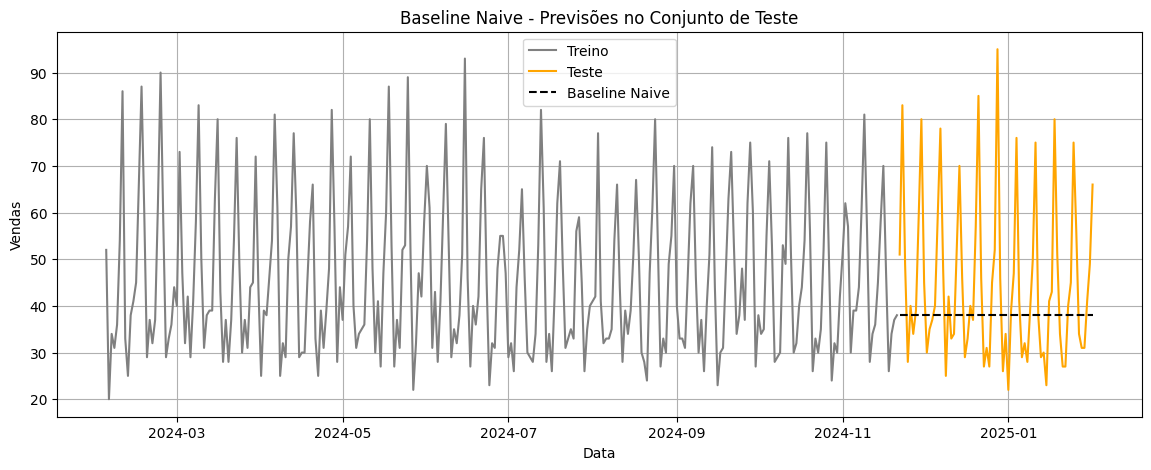

In [1476]:
plt.figure(figsize=(14, 5))
plt.plot(treino.index, treino, label='Treino', color="gray")
plt.plot(teste.index, teste, label='Teste', color="orange")

plt.plot(
    previsao_naive.index,
    previsao_naive,
    label='Baseline Naive',
    linestyle='--',
    color="black"
)

plt.title('Baseline Naive - Previsões no Conjunto de Teste')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True)
plt.show()

####**14.1.3 Métricas**

In [1477]:
mae_naive = mean_absolute_error(teste, previsao_naive)
mse_naive = mean_squared_error(teste, previsao_naive)
rmse_naive = np.sqrt(mse_naive)

mape_naive = np.mean(
    np.abs((teste - previsao_naive) / teste)
) * 100

smape_naive = np.mean(
    2 * np.abs(teste - previsao_naive) /
    (np.abs(teste) + np.abs(previsao_naive))
) * 100

# Para o Naive, o próprio erro de referência - é utilizado como base do MASE.
mae_naive_treino = np.mean(
    np.abs(treino.iloc[1:].values - treino.iloc[:-1].values)
)

mase_naive = mae_naive / mae_naive_treino

print("=== BASELINE NAIVE ===")
print(f"MAE:   {mae_naive:.4f}")
print(f"MSE:   {mse_naive:.4f}")
print(f"RMSE:  {rmse_naive:.4f}")
print(f"MAPE:  {mape_naive:.2f}%")
print(f"sMAPE: {smape_naive:.2f}%")
print(f"MASE:  {mase_naive:.4f}\n")

# Classificação dos Desempenho
if mase_naive < 1:
    classificacao_naive = "Melhor"
elif np.isclose(mase_naive, 1):
    classificacao_naive = "Equivalente"
else:
    classificacao_naive = "Pior"

# MAE
if mae_naive < 5:
    classificacao_mae_naive = "Excelente"
elif mae_naive < 10:
    classificacao_mae_naive = "Bom"
elif mae_naive < 15:
    classificacao_mae_naive = "Razoável"
else:
    classificacao_mae_naive = "Ruim"


# MSE
if mse_naive < 100:
    classificacao_mse_naive = "Excelente"
elif mse_naive < 300:
    classificacao_mse_naive = "Bom"
elif mse_naive < 500:
    classificacao_mse_naive = "Razoável"
else:
    classificacao_mse_naive = "Ruim"


# RMSE
if rmse_naive < 10:
    classificacao_rmse_naive = "Excelente"
elif rmse_naive < 15:
    classificacao_rmse_naive = "Bom"
elif rmse_naive < 20:
    classificacao_rmse_naive = "Razoável"
else:
    classificacao_rmse_naive = "Ruim"


# MAPE
if mape_naive < 10:
    classificacao_mape_naive = "Excelente"
elif mape_naive < 20:
    classificacao_mape_naive = "Bom"
elif mape_naive < 50:
    classificacao_mape_naive = "Razoável"
else:
    classificacao_mape_naive = "Ruim"


# sMAPE
if smape_naive < 10:
    classificacao_smape_naive = "Excelente"
elif smape_naive < 20:
    classificacao_smape_naive = "Bom"
elif smape_naive < 50:
    classificacao_smape_naive = "Razoável"
else:
    classificacao_smape_naive = "Ruim"


# MASE
if mase_naive < 1:
    classificacao_mase_naive = "Melhor que o Naive"
elif mase_naive == 1:
    classificacao_mase_naive = "Igual ao Naive"
else:
    classificacao_mase_naive = "Pior que o Naive"


=== BASELINE NAIVE ===
MAE:   12.9167
MSE:   334.2222
RMSE:  18.2817
MAPE:  26.24%
sMAPE: 28.16%
MASE:  0.8782



In [1478]:
print(f"MAE:   {mae_naive:.4f} → {classificacao_mae_naive}")
print(f"MSE:   {mse_naive:.4f} → {classificacao_mse_naive}")
print(f"RMSE:  {rmse_naive:.4f} → {classificacao_rmse_naive}")
print(f"MAPE:  {mape_naive:.2f}% → {classificacao_mape_naive}")
print(f"sMAPE: {smape_naive:.2f}% → {classificacao_smape_naive}")
print(f"MASE:  {mase_naive:.4f} → {classificacao_mase_naive}")

MAE:   12.9167 → Razoável
MSE:   334.2222 → Razoável
RMSE:  18.2817 → Razoável
MAPE:  26.24% → Razoável
sMAPE: 28.16% → Razoável
MASE:  0.8782 → Melhor que o Naive


####**14.1.4 Conclusão**
O MASE do modelo Naive foi de 0,8782, indicando que seu erro foi utilizado como referência para a comparação de desempenho dos demais modelos. Como o Naive é o próprio modelo de referência (baseline), seu resultado deve ser interpretado apenas como parâmetro de comparação, não sendo adequado classificá-lo como “melhor que o Naive”.

Dessa forma, os demais modelos foram avaliados em relação ao desempenho desse baseline, sendo considerados superiores quando apresentaram valores de MASE inferiores a 1. A partir dessa comparação, observou-se que os modelos Prophet, SARIMA e AutoARIMA apresentaram desempenho significativamente superior ao Naive, enquanto os modelos AR, MA e ARMA, aplicados à série diferenciada, apresentaram desempenho mais próximo ao baseline.

#**Série Orginal Sem Transformação**

##**15. Modelo ARIMA**

###**15.1 Criação do Modelo**

In [1479]:
resultado_arima = ARIMA(
    treino,
    order=(1, 0, 0)
).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [1480]:
print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 Vendas   No. Observations:                  292
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1202.665
Date:                Tue, 08 Sep 2026   AIC                           2411.331
Time:                        22:54:07   BIC                           2422.361
Sample:                    02-04-2024   HQIC                          2415.749
                         - 11-21-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.4687      1.753     25.939      0.000      42.033      48.904
ar.L1          0.3812      0.076      5.026      0.000       0.233       0.530
sigma2       221.1846     20.859     10.604      0.0

###**15.2 Modelo de Previsão**

In [1481]:
previsao_arima = resultado_arima.forecast(
    steps=len(teste)
)

previsao_arima.index = teste.index
print(previsao_arima.head())

Data
2024-11-22    42.621321
2024-11-23    44.383163
2024-11-24    45.054852
2024-11-25    45.310928
2024-11-26    45.408555
Name: predicted_mean, dtype: float64


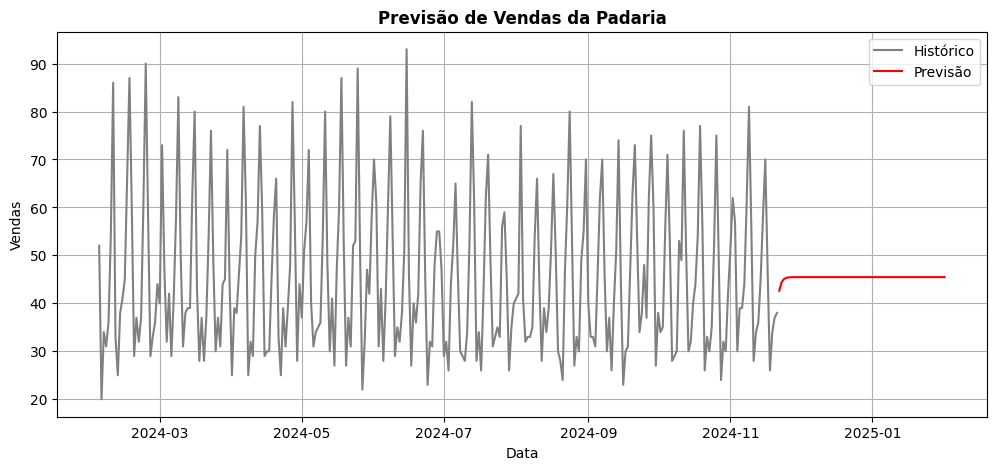

In [1482]:
plt.figure(figsize=(12, 5))
plt.plot(treino, label="Histórico", color='gray')
plt.plot(previsao_arima, label="Previsão", color="red")
plt.title("Previsão de Vendas da Padaria", fontweight='bold')
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid()
plt.show()

###**15.3 Comparação**

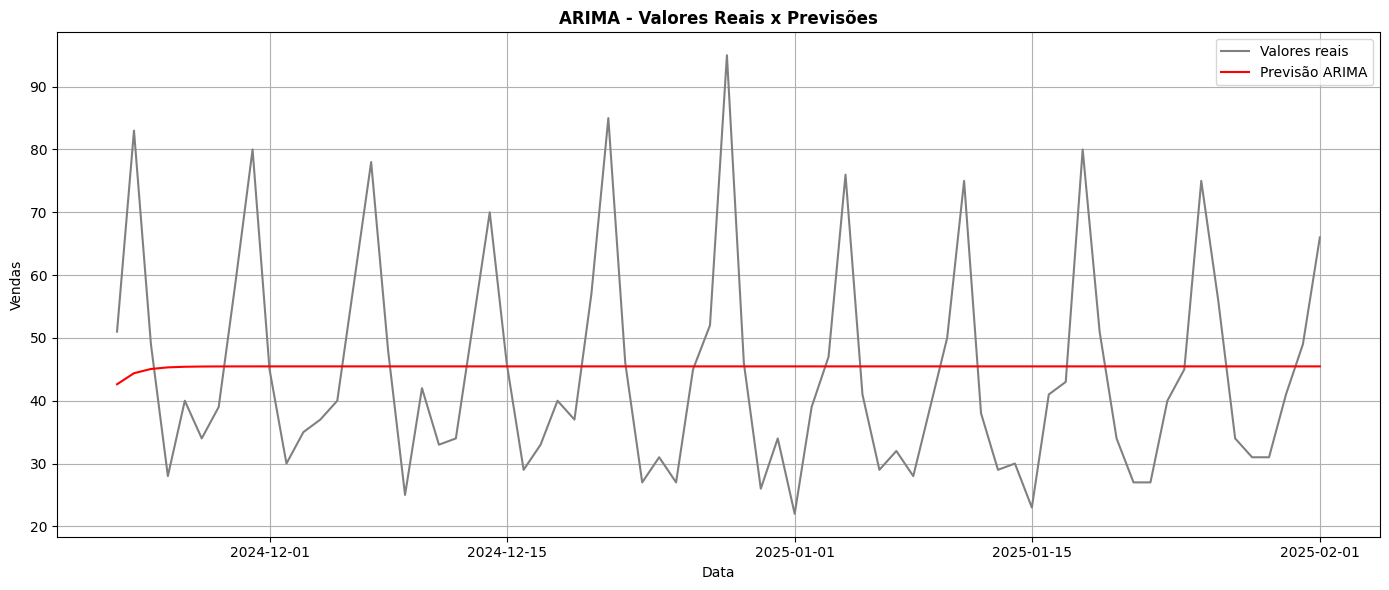

In [1483]:
plt.figure(figsize=(14, 6))

plt.plot(
    teste.index,
    teste.values,
    label="Valores reais",
    color='gray'
)

plt.plot(
    previsao_arima.index,
    previsao_arima.values,
    label="Previsão ARIMA",
    color="red"
)

plt.title("ARIMA - Valores Reais x Previsões", fontweight='bold')
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###**15.4 Métricas**

In [1484]:
y_real = teste.values
y_pred = previsao_arima.values

# MAE
mae_arima = mean_absolute_error(y_real, y_pred)

# MSE
mse_arima = mean_squared_error(y_real, y_pred)

# RMSE
rmse_arima = np.sqrt(mse_arima)

# MAPE
mape_arima = np.mean(
    np.abs((y_real - y_pred) / y_real)
) * 100

# sMAPE
smape_arima = np.mean(
    2 * np.abs(y_pred - y_real) /
    (np.abs(y_real) + np.abs(y_pred))
) * 100

print("Resultados do ARIMA")
print("--------------------")
print(f"MAE:   {mae_arima:.4f}")
print(f"MSE:   {mse_arima:.4f}")
print(f"RMSE:  {rmse_arima:.4f}")
print(f"MAPE:  {mape_arima:.2f}%")
print(f"sMAPE: {smape_arima:.2f}%")

# MAE
if mae_arima < 5:
    classificacao_mae_arima = "Excelente"
elif mae_arima < 10:
    classificacao_mae_arima = "Bom"
elif mae_arima < 15:
    classificacao_mae_arima = "Razoável"
else:
    classificacao_mae_arima = "Ruim"


# MSE
if mse_arima < 100:
    classificacao_mse_arima = "Excelente"
elif mse_arima < 300:
    classificacao_mse_arima = "Bom"
elif mse_arima < 500:
    classificacao_mse_arima = "Razoável"
else:
    classificacao_mse_arima = "Ruim"


# RMSE
if rmse_arima < 10:
    classificacao_rmse_arima = "Excelente"
elif rmse_arima < 15:
    classificacao_rmse_arima = "Bom"
elif rmse_arima < 20:
    classificacao_rmse_arima = "Razoável"
else:
    classificacao_rmse_arima = "Ruim"


# MAPE
if mape_arima < 10:
    classificacao_mape_arima = "Excelente"
elif mape_arima < 20:
    classificacao_mape_arima = "Bom"
elif mape_arima < 50:
    classificacao_mape_arima = "Razoável"
else:
    classificacao_mape_arima = "Ruim"


# sMAPE
if smape_arima < 10:
    classificacao_smape_arima = "Excelente"
elif smape_arima < 20:
    classificacao_smape_arima = "Bom"
elif smape_arima < 50:
    classificacao_smape_arima = "Razoável"
else:
    classificacao_smape_arima = "Ruim"


# MASE
if mase_arima < 1:
    classificacao_mase_arima = "Melhor que o Naive"
elif np.isclose(mase_arima, 1):
    classificacao_mase_arima = "Igual ao Naive"
else:
    classificacao_mase_arima = "Pior que o Naive"


Resultados do ARIMA
--------------------
MAE:   13.4519
MSE:   292.0704
RMSE:  17.0901
MAPE:  32.50%
sMAPE: 29.41%


In [1485]:
print(f"MAE:   {mae_arima:.4f} → {classificacao_mae_arima}")
print(f"MSE:   {mse_arima:.4f} → {classificacao_mse_arima}")
print(f"RMSE:  {rmse_arima:.4f} → {classificacao_rmse_arima}")
print(f"MAPE:  {mape_arima:.2f}% → {classificacao_mape_arima}")
print(f"sMAPE: {smape_arima:.2f}% → {classificacao_smape_arima}")
print(f"MASE:  {mase_arima:.4f} → {classificacao_mase_arima}")

MAE:   13.4519 → Razoável
MSE:   292.0704 → Bom
RMSE:  17.0901 → Razoável
MAPE:  32.50% → Razoável
sMAPE: 29.41% → Razoável
MASE:  0.9146 → Melhor que o Naive


##**16. Modelo SARIMA**

###**16.1 Criação do Modelo**

In [1486]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(
    treino,
    # Parte não sazonal: (p, d, q)
    order=(1, 1, 1),
    # Parte sazonal: (P, D, Q, s)
    # s = 7 porque os dados semanais
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo.fit(disp=False)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [1487]:
print(resultado_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            Vendas   No. Observations:                  292
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -882.742
Date:                           Tue, 08 Sep 2026   AIC                           1775.485
Time:                                   22:54:09   BIC                           1793.569
Sample:                               02-04-2024   HQIC                          1782.742
                                    - 11-21-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1265      0.064      1.976      0.048       0.001       0.252
ma.L1         -0.9746      0.023    -41.759

###**16.2. Modelo de Previsão**

In [1488]:
previsao_sarima = resultado_sarima.forecast(
    steps=len(teste)
)

# Garantir o mesmo índice do conjunto de teste
previsao_sarima.index = teste.index
print(previsao_sarima.head())

Data
2024-11-22    55.106211
2024-11-23    73.736153
2024-11-24    50.792809
2024-11-25    28.203852
2024-11-26    34.564526
Name: predicted_mean, dtype: float64


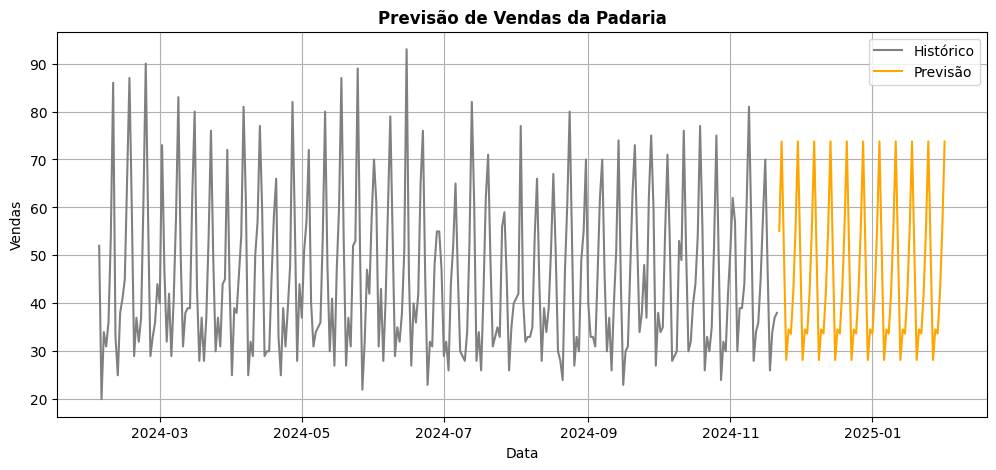

In [1489]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(treino, label="Histórico", color='gray')
plt.plot(previsao_sarima, label="Previsão", color="orange")
plt.title("Previsão de Vendas da Padaria", fontweight='bold')
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid()
plt.show()

###**16.3 Comparação**

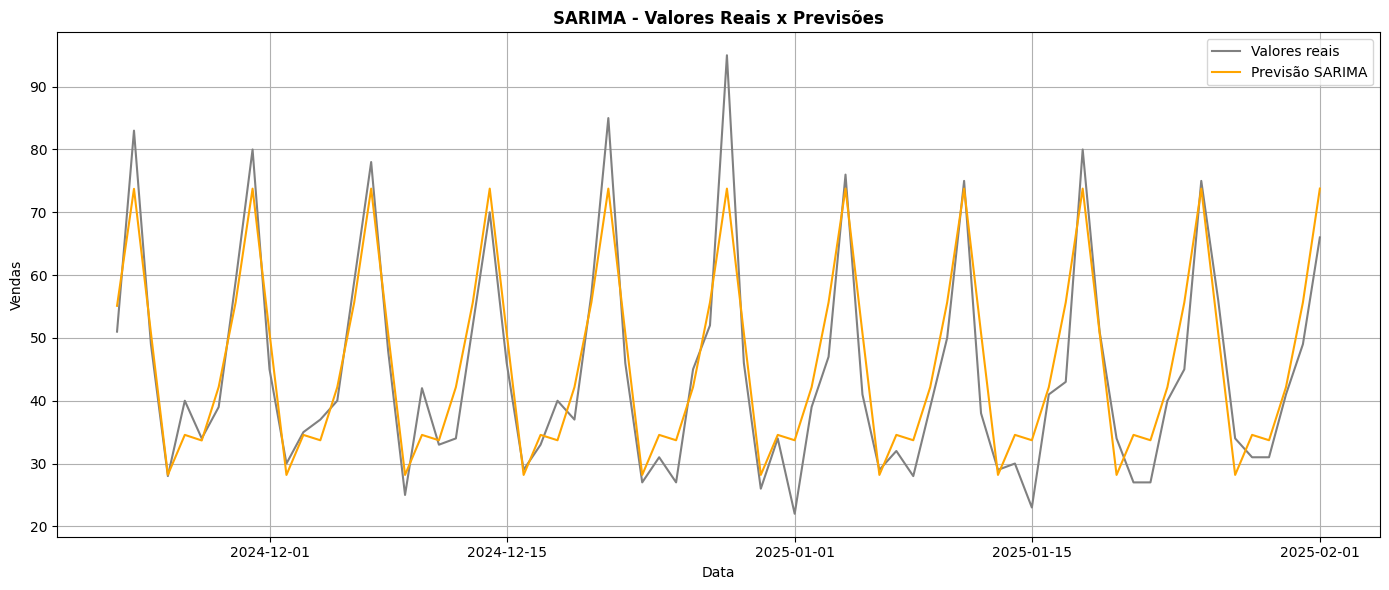

In [1490]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    teste.index,
    teste.values,
    label="Valores reais",
    color='gray'
)

plt.plot(
    previsao_sarima.index,
    previsao_sarima.values,
    label="Previsão SARIMA",
    color="orange"
)

plt.title("SARIMA - Valores Reais x Previsões", fontweight='bold')
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

###**16.4 Métricas**

In [1491]:
y_real = teste.values
y_pred = previsao_sarima.values

# MAE
mae_sarima = mean_absolute_error(y_real, y_pred)

# MSE
mse_sarima = mean_squared_error(y_real, y_pred)

# RMSE
rmse_sarima = np.sqrt(mse_sarima)

# MAPE
mape_sarima = np.mean(
    np.abs((y_real - y_pred) / y_real)
) * 100

# sMAPE
smape_sarima = np.mean(
    2 * np.abs(y_pred - y_real) /
    (np.abs(y_real) + np.abs(y_pred))
) * 100

print("Resultados do SARIMA")
print("--------------------")
print(f"MAE:   {mae_sarima:.4f}")
print(f"MSE:   {mse_sarima:.4f}")
print(f"RMSE:  {rmse_sarima:.4f}")
print(f"MAPE:  {mape_sarima:.2f}%")
print(f"sMAPE: {smape_sarima:.2f}%")

# MAE
if mae_sarima < 5:
    classificacao_mae_sarima = "Excelente"
elif mae_sarima < 10:
    classificacao_mae_sarima = "Bom"
elif mae_sarima < 15:
    classificacao_mae_sarima = "Razoável"
else:
    classificacao_mae_sarima = "Ruim"


# MSE
if mse_sarima < 100:
    classificacao_mse_sarima = "Excelente"
elif mse_sarima < 300:
    classificacao_mse_sarima = "Bom"
elif mse_sarima < 500:
    classificacao_mse_sarima = "Razoável"
else:
    classificacao_mse_sarima = "Ruim"


# RMSE
if rmse_sarima < 10:
    classificacao_rmse_sarima = "Excelente"
elif rmse_sarima < 15:
    classificacao_rmse_sarima = "Bom"
elif rmse_sarima < 20:
    classificacao_rmse_sarima = "Razoável"
else:
    classificacao_rmse_sarima = "Ruim"


# MAPE
if mape_sarima < 10:
    classificacao_mape_sarima = "Excelente"
elif mape_sarima < 20:
    classificacao_mape_sarima = "Bom"
elif mape_sarima < 50:
    classificacao_mape_sarima = "Razoável"
else:
    classificacao_mape_sarima = "Ruim"


# sMAPE
if smape_sarima < 10:
    classificacao_smape_sarima = "Excelente"
elif smape_sarima < 20:
    classificacao_smape_sarima = "Bom"
elif smape_sarima < 50:
    classificacao_smape_sarima = "Razoável"
else:
    classificacao_smape_sarima = "Ruim"


# MASE
if mase_sarima < 1:
    classificacao_mase_sarima = "Melhor que o Naive"
elif np.isclose(mase_sarima, 1):
    classificacao_mase_sarima = "Igual ao Naive"
else:
    classificacao_mase_sarima = "Pior que o Naive"


Resultados do SARIMA
--------------------
MAE:   4.6955
MSE:   36.0408
RMSE:  6.0034
MAPE:  11.44%
sMAPE: 10.79%


In [1492]:
print("\nClassificação do desempenho:")
print(f"MAE:   {mae_sarima:.4f} → {classificacao_mae_sarima}")
print(f"MSE:   {mse_sarima:.4f} → {classificacao_mse_sarima}")
print(f"RMSE:  {rmse_sarima:.4f} → {classificacao_rmse_sarima}")
print(f"MAPE:  {mape_sarima:.2f}% → {classificacao_mape_sarima}")
print(f"sMAPE: {smape_sarima:.2f}% → {classificacao_smape_sarima}")
print(f"MASE:  {mase_sarima:.4f} → {classificacao_mase_sarima}")


Classificação do desempenho:
MAE:   4.6955 → Excelente
MSE:   36.0408 → Excelente
RMSE:  6.0034 → Excelente
MAPE:  11.44% → Bom
sMAPE: 10.79% → Bom
MASE:  0.3192 → Melhor que o Naive


##**17. Modelo PROPHET**

In [1493]:
# Preparando os dados de treino para o Prophet
df_prophet = treino.reset_index()
df_prophet = df_prophet.rename(columns={
    "Data": "ds",
    "Vendas": "y"
})

#df_prophet.head()

# Criando o modelo Prophet
modelo_prophet = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False
)

# Treinando o modelo
modelo_prophet.fit(df_prophet)

###**17.1 Modelo de Previsão**

In [1494]:
# Número de períodos que precisamos prever
horizonte = len(teste)

# Criando datas futuras
datas_futuras = modelo_prophet.make_future_dataframe(
    periods=horizonte,
    freq='D'
)

datas_futuras.tail()

,ds
359,2025-01-28
360,2025-01-29
361,2025-01-30
362,2025-01-31
363,2025-02-01


In [1495]:
# Gerando as previsões
previsao_prophet = modelo_prophet.predict(datas_futuras)

# Selecionando apenas o período correspondente ao teste
previsao_prophet_teste = previsao_prophet[
    previsao_prophet["ds"].isin(teste.index)
].copy()

# Visualizando as previsões
previsao_prophet_teste[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
292,2024-11-22,55.469230,48.488067,63.213325
293,2024-11-23,75.480095,68.250426,83.143989
294,2024-11-24,49.853048,42.328672,57.105604
295,2024-11-25,27.983483,20.445117,34.775746
296,2024-11-26,35.208807,28.177906,42.430405


In [1496]:
previsao_prophet_teste.index = pd.to_datetime(
    previsao_prophet_teste["ds"]
)

previsao_prophet_series = previsao_prophet_teste["yhat"]
previsao_prophet_series.head()

,yhat
ds,
2024-11-22,55.469230
2024-11-23,75.480095
2024-11-24,49.853048
2024-11-25,27.983483
2024-11-26,35.208807


###**17.2 Comparação**

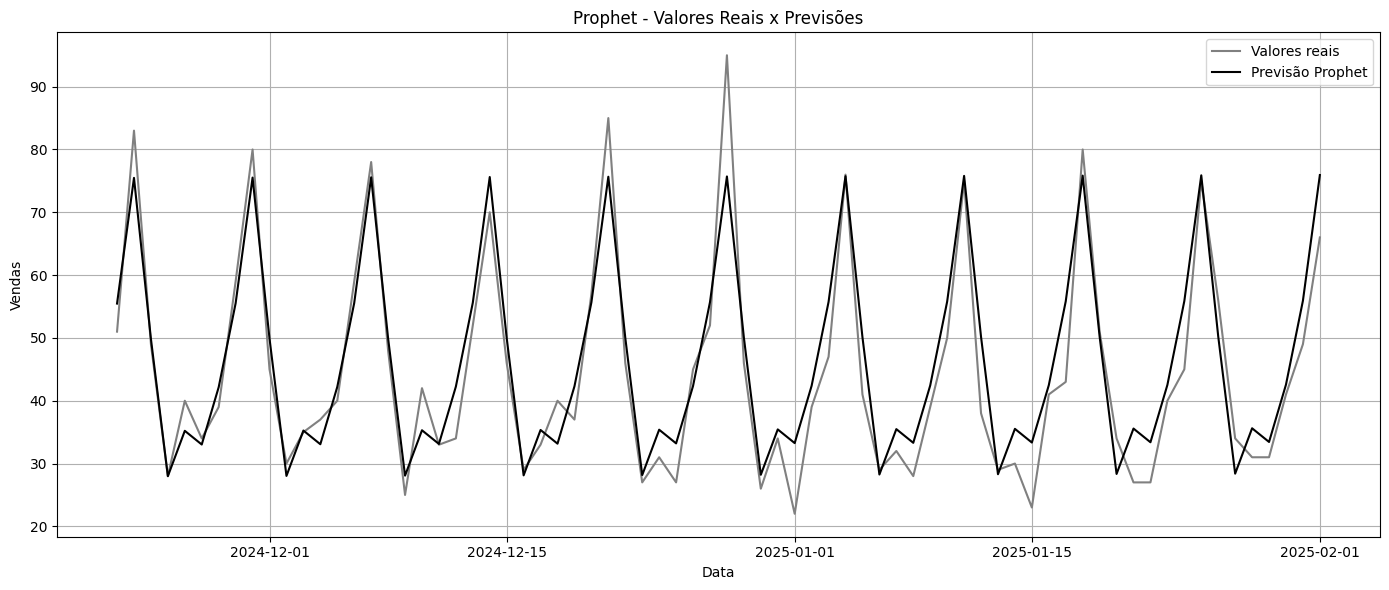

In [1497]:
plt.figure(figsize=(14, 6))

plt.plot(
    teste.index,
    teste.values,
    label="Valores reais",
    color="gray"
)

plt.plot(
    previsao_prophet_series.index,
    previsao_prophet_series.values,
    label="Previsão Prophet",
    color="black"
)

plt.title("Prophet - Valores Reais x Previsões")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###**17.3 Previsão**

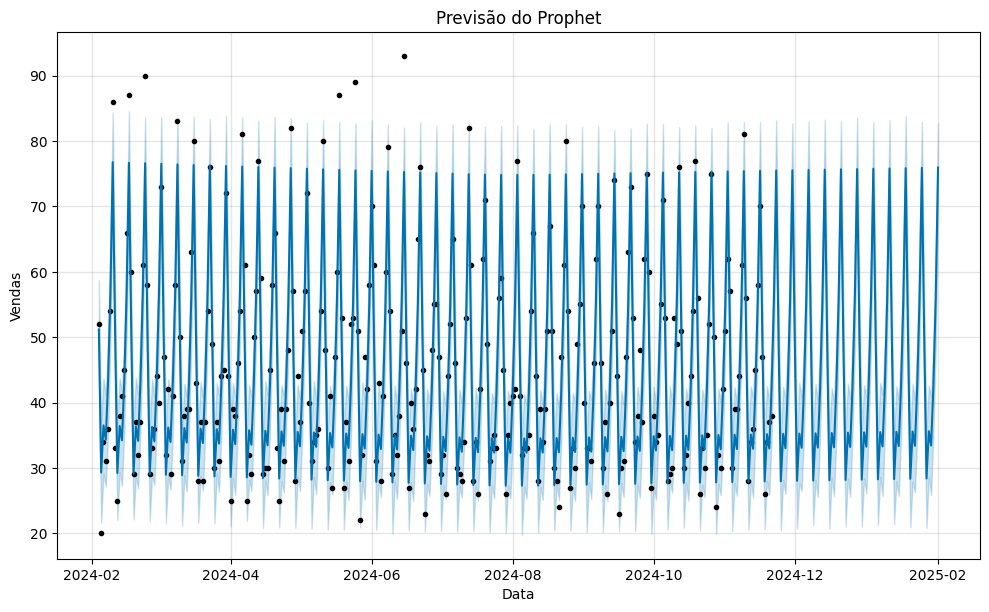

In [1498]:
fig1 = modelo_prophet.plot(previsao_prophet)
plt.title("Previsão do Prophet")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

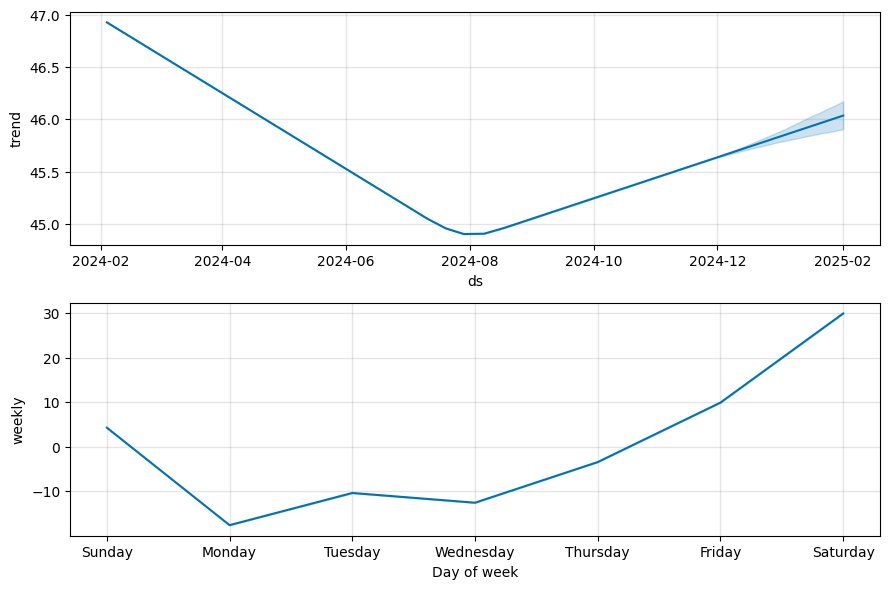

In [1499]:
fig2 = modelo_prophet.plot_components(previsao_prophet)
plt.show()

###**17.4 Métricas**

In [1500]:
y_real = teste.values
y_pred = previsao_prophet_series.values

# MAE
mae_prophet = mean_absolute_error(y_real, y_pred)

# MSE
mse_prophet = mean_squared_error(y_real, y_pred)

# RMSE
rmse_prophet = np.sqrt(mse_prophet)

# MAPE
mape_prophet = np.mean(
    np.abs((y_real - y_pred) / y_real)
) * 100

# sMAPE
smape_prophet = np.mean(
    2 * np.abs(y_pred - y_real) /
    (np.abs(y_real) + np.abs(y_pred))
) * 100

print("Resultados do Prophet")
print("----------------------")
print(f"MAE:   {mae_prophet:.4f}")
print(f"MSE:   {mse_prophet:.4f}")
print(f"RMSE:  {rmse_prophet:.4f}")
print(f"MAPE:  {mape_prophet:.2f}%")
print(f"sMAPE: {smape_prophet:.2f}%")

# MAE
if mae_prophet < 5:
    classificacao_mae_prophet = "Excelente"
elif mae_prophet < 10:
    classificacao_mae_prophet = "Bom"
elif mae_prophet < 15:
    classificacao_mae_prophet = "Razoável"
else:
    classificacao_mae_prophet = "Ruim"


# MSE
if mse_prophet < 100:
    classificacao_mse_prophet = "Excelente"
elif mse_prophet < 300:
    classificacao_mse_prophet = "Bom"
elif mse_prophet < 500:
    classificacao_mse_prophet = "Razoável"
else:
    classificacao_mse_prophet = "Ruim"


# RMSE
if rmse_prophet < 10:
    classificacao_rmse_prophet = "Excelente"
elif rmse_prophet < 15:
    classificacao_rmse_prophet = "Bom"
elif rmse_prophet < 20:
    classificacao_rmse_prophet = "Razoável"
else:
    classificacao_rmse_prophet = "Ruim"


# MAPE
if mape_prophet < 10:
    classificacao_mape_prophet = "Excelente"
elif mape_prophet < 20:
    classificacao_mape_prophet = "Bom"
elif mape_prophet < 50:
    classificacao_mape_prophet = "Razoável"
else:
    classificacao_mape_prophet = "Ruim"


# sMAPE
if smape_prophet < 10:
    classificacao_smape_prophet = "Excelente"
elif smape_prophet < 20:
    classificacao_smape_prophet = "Bom"
elif smape_prophet < 50:
    classificacao_smape_prophet = "Razoável"
else:
    classificacao_smape_prophet = "Ruim"


# MASE
if mase_prophet < 1:
    classificacao_mase_prophet = "Melhor que o Naive"
elif np.isclose(mase_prophet, 1):
    classificacao_mase_prophet = "Igual ao Naive"
else:
    classificacao_mase_prophet = "Pior que o Naive"

Resultados do Prophet
----------------------
MAE:   4.5744
MSE:   33.6862
RMSE:  5.8040
MAPE:  11.35%
sMAPE: 10.68%


In [1501]:
print("\nClassificação do desempenho:")
print(f"MAE:   {mae_prophet:.4f} → {classificacao_mae_prophet}")
print(f"MSE:   {mse_prophet:.4f} → {classificacao_mse_prophet}")
print(f"RMSE:  {rmse_prophet:.4f} → {classificacao_rmse_prophet}")
print(f"MAPE:  {mape_prophet:.2f}% → {classificacao_mape_prophet}")
print(f"sMAPE: {smape_prophet:.2f}% → {classificacao_smape_prophet}")
print(f"MASE:  {mase_prophet:.4f} → {classificacao_mase_prophet}")


Classificação do desempenho:
MAE:   4.5744 → Excelente
MSE:   33.6862 → Excelente
RMSE:  5.8040 → Excelente
MAPE:  11.35% → Bom
sMAPE: 10.68% → Bom
MASE:  0.3110 → Melhor que o Naive


##**18. Auto ARIMA**

O **AutoARIMA** é uma técnica que automatiza a escolha dos melhores parâmetros de um modelo ARIMA/SARIMA para uma série temporal. No código apresentado, a função `auto_arima()` analisa os dados de `treino` e testa diferentes combinações de parâmetros, considerando a existência de sazonalidade (`seasonal=True`) com um ciclo de 7 períodos (`m=7`), adequado, por exemplo, para dados diários com comportamento semanal. O parâmetro `stepwise=True` torna a busca mais eficiente, enquanto `trace=True` permite acompanhar no console os modelos testados. Ao final, `modelo.summary()` apresenta os parâmetros e estatísticas do modelo selecionado, facilitando a análise e posterior utilização para realizar previsões.


###**18.1 Modelo de Previsão**

In [1502]:
modelo_auto_arima = auto_arima(
    treino,
    seasonal=True,
    m=7,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=2104.278, Time=4.03 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2455.311, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=2049.779, Time=1.24 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=2230.288, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=3094.279, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=2411.332, Time=0.10 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=inf, Time=2.26 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=2012.555, Time=0.92 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=2240.790, Time=0.27 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=1908.420, Time=1.95 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=2215.033, Time=2.21 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=2023.141, Time=1.68 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=1908.965, Time=4.45 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=1907.935, Time=2.23 sec
 ARIMA(2,0,0)(1,0,1)[7] intercept   : 

/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,0,1)(2,0,1)[7] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
    ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
        start_params=start_params,
    ...<3 lines>...
        **fit_args,
    )
  File "/usr/loc

 ARIMA(2,0,1)(2,0,1)[7] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,0,1)(2,0,1)[7] intercept   : AIC=inf, Time=2.42 sec
 ARIMA(3,0,1)(2,0,1)[7] intercept   : AIC=inf, Time=3.04 sec
 ARIMA(2,0,0)(2,0,1)[7]             : AIC=1912.470, Time=1.17 sec

Best model:  ARIMA(2,0,0)(2,0,1)[7] intercept
Total fit time: 42.874 seconds


In [1503]:
print(modelo_auto_arima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  292
Model:             SARIMAX(2, 0, 0)x(2, 0, [1], 7)   Log Likelihood                -946.968
Date:                             Tue, 08 Sep 2026   AIC                           1907.935
Time:                                     22:54:53   BIC                           1933.673
Sample:                                 02-04-2024   HQIC                          1918.245
                                      - 11-21-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1630      0.102      1.603      0.109      -0.036       0.362
ar.L1          0.1683      

In [1504]:
print("Modelo selecionado:")
print(modelo_auto_arima.order)

print("Ordem sazonal:")
print(modelo_auto_arima.seasonal_order)

Modelo selecionado:
(2, 0, 0)
Ordem sazonal:
(2, 0, 1, 7)


###**18.2 Previsão**

In [1505]:
previsao_auto_arima = modelo_auto_arima.predict(
    n_periods=len(teste)
)

previsao_auto_arima = pd.Series(
    previsao_auto_arima,
    index=teste.index
)

print(previsao_auto_arima.head())

Data
2024-11-22    54.359929
2024-11-23    72.326040
2024-11-24    52.071247
2024-11-25    28.348834
2024-11-26    34.379190
dtype: float64


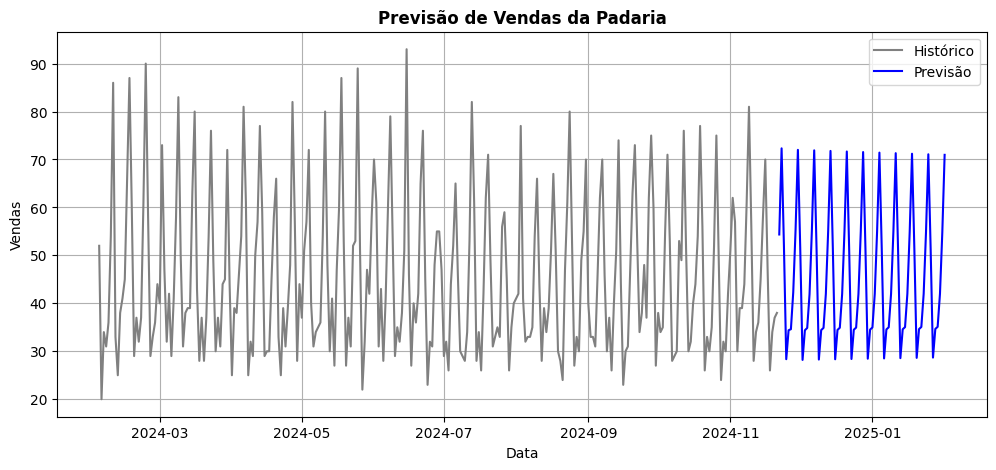

In [1506]:
plt.figure(figsize=(12, 5))
plt.plot(treino, label="Histórico", color='Gray')
plt.plot(previsao_auto_arima, label="Previsão", color="Blue")
plt.title("Previsão de Vendas da Padaria", fontweight='bold')
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid()
plt.show()

###**18.3 Comparação**

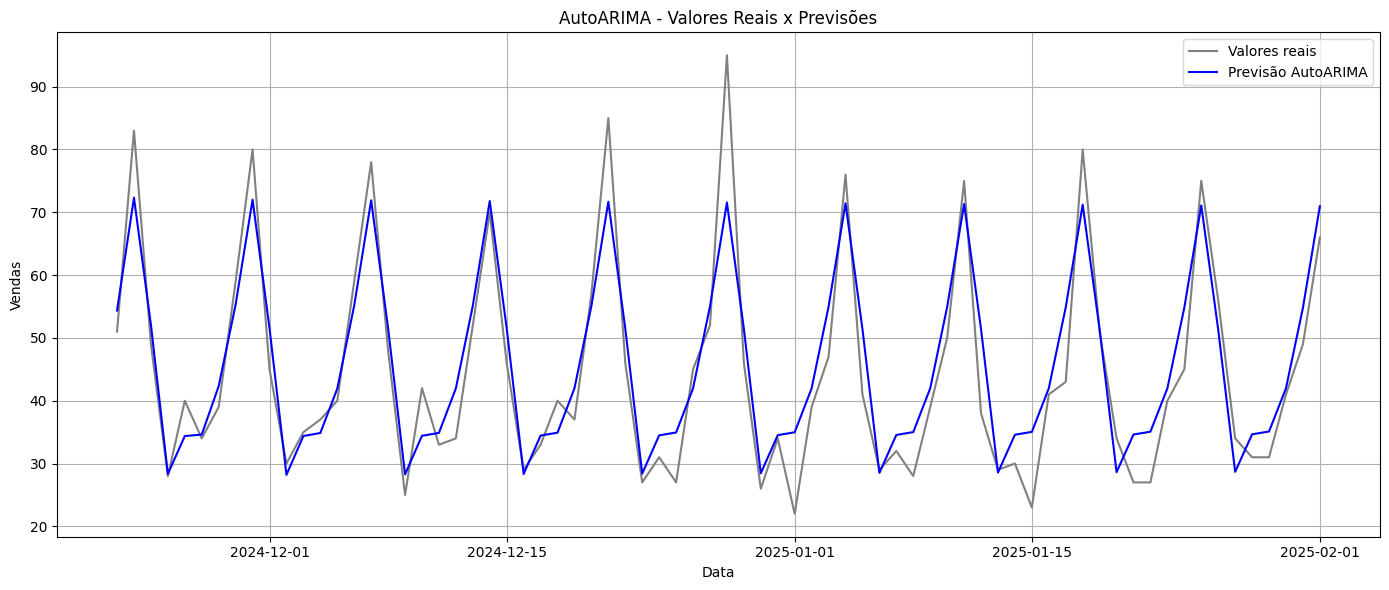

In [1507]:
plt.figure(figsize=(14, 6))

plt.plot(
    teste.index,
    teste.values,
    label="Valores reais",
    color="Gray"
)

plt.plot(
    previsao_auto_arima.index,
    previsao_auto_arima.values,
    label="Previsão AutoARIMA",
    color="Blue"
)

plt.title("AutoARIMA - Valores Reais x Previsões")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###**18.4 Métricas**

In [1508]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_real = teste.values
y_pred = previsao_auto_arima.values

# MAE
mae_autoarima = mean_absolute_error(y_real, y_pred)

# MSE
mse_autoarima = mean_squared_error(y_real, y_pred)

# RMSE
rmse_autoarima = np.sqrt(mse_autoarima)

# MAPE
mape_autoarima = np.mean(
    np.abs((y_real - y_pred) / y_real)
) * 100

# sMAPE
smape_autoarima = np.mean(
    2 * np.abs(y_pred - y_real) /
    (np.abs(y_real) + np.abs(y_pred))
) * 100

# MASE
y_treino = treino.values

mae_naive_treino = np.mean(
    np.abs(y_treino[1:] - y_treino[:-1])
)

mase_autoarima = (
    mae_autoarima / mae_naive_treino
)

print("Resultados do AutoARIMA")
print("-----------------------")
print(f"MAE:   {mae_autoarima:.4f}")
print(f"MSE:   {mse_autoarima:.4f}")
print(f"RMSE:  {rmse_autoarima:.4f}")
print(f"MAPE:  {mape_autoarima:.2f}%")
print(f"sMAPE: {smape_autoarima:.2f}%")
print(f"MASE:  {mase_autoarima:.4f}")

# MAE
if mae_autoarima < 5:
    classificacao_mae_autoarima = "Excelente"
elif mae_autoarima < 10:
    classificacao_mae_autoarima = "Bom"
elif mae_autoarima < 15:
    classificacao_mae_autoarima = "Razoável"
else:
    classificacao_mae_autoarima = "Ruim"


# MSE
if mse_autoarima < 100:
    classificacao_mse_autoarima = "Excelente"
elif mse_autoarima < 300:
    classificacao_mse_autoarima = "Bom"
elif mse_autoarima < 500:
    classificacao_mse_autoarima = "Razoável"
else:
    classificacao_mse_autoarima = "Ruim"


# RMSE
if rmse_autoarima < 10:
    classificacao_rmse_autoarima = "Excelente"
elif rmse_autoarima < 15:
    classificacao_rmse_autoarima = "Bom"
elif rmse_autoarima < 20:
    classificacao_rmse_autoarima = "Razoável"
else:
    classificacao_rmse_autoarima = "Ruim"


# MAPE
if mape_autoarima < 10:
    classificacao_mape_autoarima = "Excelente"
elif mape_autoarima < 20:
    classificacao_mape_autoarima = "Bom"
elif mape_autoarima < 50:
    classificacao_mape_autoarima = "Razoável"
else:
    classificacao_mape_autoarima = "Ruim"


# sMAPE
if smape_autoarima < 10:
    classificacao_smape_autoarima = "Excelente"
elif smape_autoarima < 20:
    classificacao_smape_autoarima = "Bom"
elif smape_autoarima < 50:
    classificacao_smape_autoarima = "Razoável"
else:
    classificacao_smape_autoarima = "Ruim"


# MASE
if mase_autoarima < 1:
    classificacao_mase_autoarima = "Melhor que o Naive"
elif np.isclose(mase_autoarima, 1):
    classificacao_mase_autoarima = "Igual ao Naive"
else:
    classificacao_mase_autoarima = "Pior que o Naive"

Resultados do AutoARIMA
-----------------------
MAE:   4.9902
MSE:   40.8909
RMSE:  6.3946
MAPE:  12.05%
sMAPE: 11.32%
MASE:  0.3393


In [1509]:
print("\nClassificação do desempenho:")
print(f"MAE:   {mae_autoarima:.4f} → {classificacao_mae_autoarima}")
print(f"MSE:   {mse_autoarima:.4f} → {classificacao_mse_autoarima}")
print(f"RMSE:  {rmse_autoarima:.4f} → {classificacao_rmse_autoarima}")
print(f"MAPE:  {mape_autoarima:.2f}% → {classificacao_mape_autoarima}")
print(f"sMAPE: {smape_autoarima:.2f}% → {classificacao_smape_autoarima}")
print(f"MASE:  {mase_autoarima:.4f} → {classificacao_mase_autoarima}")


Classificação do desempenho:
MAE:   4.9902 → Excelente
MSE:   40.8909 → Excelente
RMSE:  6.3946 → Excelente
MAPE:  12.05% → Bom
sMAPE: 11.32% → Bom
MASE:  0.3393 → Melhor que o Naive


###**18.5 Conclusão**
O resultado mostra que o AutoARIMA testou diversas combinações de modelos e selecionou automaticamente o SARIMA(2,0,0)(2,0,1)[7] com intercepto, por apresentar o menor AIC entre os modelos avaliados, com valor de 1907,935.

O modelo utiliza dois termos autorregressivos não sazonais (AR(2)) e componentes sazonais com período de 7 observações, indicando a presença de um padrão semanal. Os coeficientes ar.L1, ar.S.L7 e ma.S.L7 são estatisticamente significativos (p < 0,05), enquanto ar.L2, ar.S.L14 e o intercepto não apresentam significância estatística.

O teste de Ljung-Box apresentou p = 0,61, sugerindo que não há autocorrelação significativa nos resíduos no primeiro lag, embora o teste de Jarque-Bera (p < 0,001) indique que os resíduos não seguem uma distribuição normal.

Durante a busca, alguns modelos apresentaram AIC=inf e um erro de decomposição LU, mas isso não impediu o AutoARIMA de concluir a seleção do modelo. Portanto, o modelo escolhido é uma boa candidata para realizar previsões, mas seu desempenho deve ser validado em dados de teste antes de ser utilizado definitivamente.

#**18. Transformação e Diferenciação**

Como etapa de preparação para a modelagem, foi realizada a diferenciação de primeira ordem da série temporal. Essa transformação será utilizada para a construção dos modelos AR, MA e ARMA sobre a série transformada.

In [1510]:
treino_dif = treino.diff().dropna()

print("Treino original:", len(treino))
print("Treino diferenciado:", len(treino_dif))

Treino original: 292
Treino diferenciado: 291


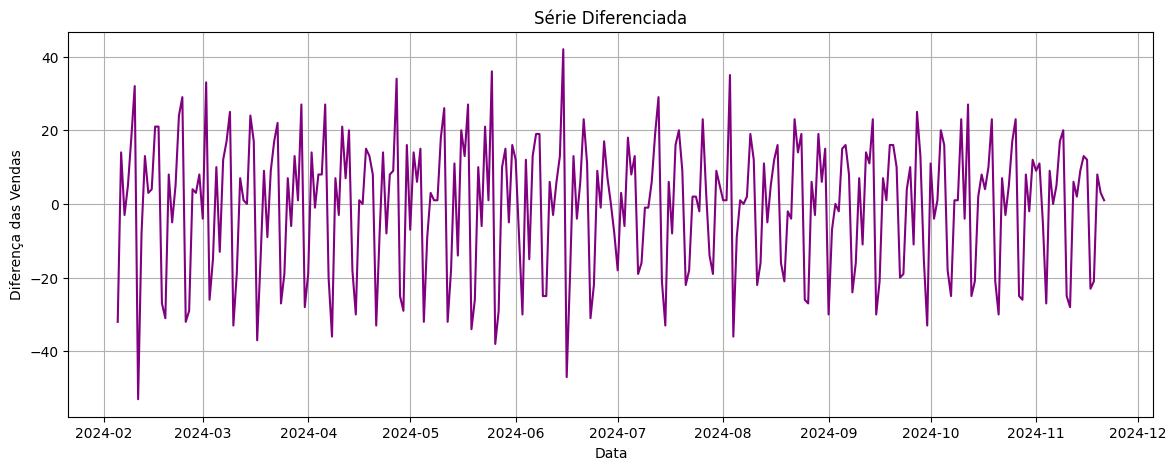

In [1511]:
plt.figure(figsize=(14,5))
plt.plot(treino_dif, color='purple')
plt.title("Série Diferenciada")
plt.xlabel("Data")
plt.ylabel("Diferença das Vendas")
plt.grid(True)
plt.show()

##**18.1 Novos Testes de Estacionaridade**

## **18.2 ACF (Autocorrelation Function)**
Mostra a correlação da série com seus próprios valores anteriores (lags).

In [1512]:
resultado_adf = adfuller(treino_dif)

print("ADF:", resultado_adf[0])
print("p-valor:", resultado_adf[1])

if resultado_adf[1] < 0.05:
    print("Série diferenciada estacionária.")
else:
    print("Série diferenciada não estacionária.")

ADF: -8.706547801572619
p-valor: 3.686993958355259e-14
Série diferenciada estacionária.


##**18.3 PACF (Partial Autocorrelation Function)**
Mostra a correlação entre a série e seus valores anteriores, eliminando o efeito dos lags intermediários.

In [1513]:
estatistica, p_valor, lags, criticos = kpss(
    treino_dif,
    regression='c'
)

print("KPSS:", estatistica)
print("p-valor:", p_valor)

if p_valor > 0.05:
    print("Série estacionária.")
else:
    print("Série não estacionária.")

KPSS: 0.20701914157397028
p-valor: 0.1
Série estacionária.


/tmp/ipykernel_5909/2890523555.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  estatistica, p_valor, lags, criticos = kpss(


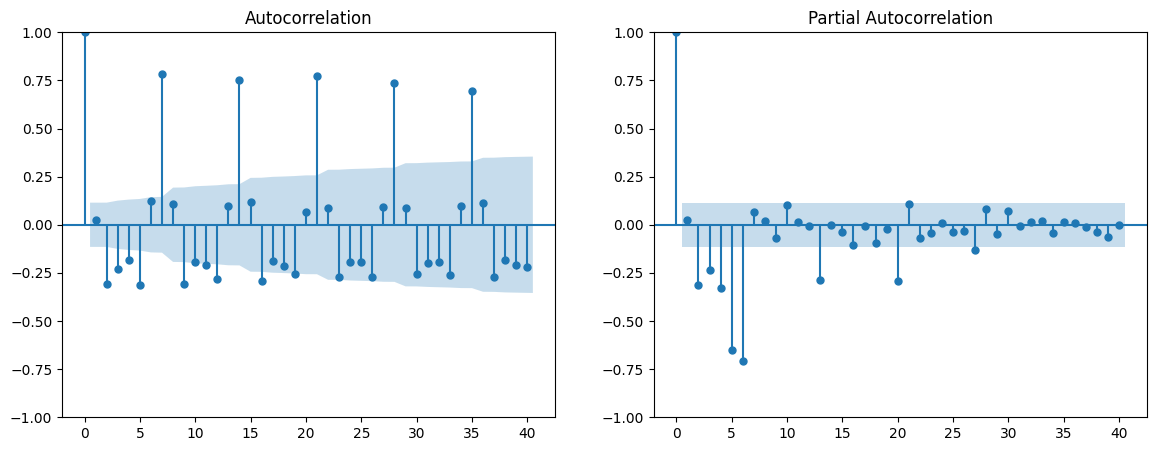

In [1514]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(treino_dif, lags=40, ax=ax[0])
plot_pacf(treino_dif, lags=40, ax=ax[1])

plt.show()

## **18.4 Conclusão**

Embora os testes de estacionaridade ADF e KPSS tenham indicado que a série original de vendas **já apresentava comportamento estacionário**, foi realizada uma **transformação adicional por meio da diferenciação de primeira ordem**. Essa etapa foi incluída para **atender à estratégia experimental proposta no projeto, permitindo comparar modelos ajustados na série original com modelos ajustados na série transformada.**

A diferenciação foi obtida pela subtração entre valores consecutivos da série temporal:

Y't = Yt - Yt-1

Após a transformação, foram **reaplicados os testes de estacionaridade e as análises de autocorrelação (ACF) e autocorrelação parcial (PACF), confirmando a adequação da série diferenciada para a modelagem utilizando os modelos AR, MA e ARMA**.


#**Série Transformada**

Usando o **treino_dif** realizado no tópico 18

##**19. AR — AutoRegressive**
Modelo usa valores passados da própria série para prever o próximo valor.

####**19.1 Criação do Modelo**

In [1515]:
modelo_ar = AutoReg(
    treino_dif,
    lags=1,
    trend='c'
).fit()

print(modelo_ar.summary(),'\n')

                            AutoReg Model Results                             
Dep. Variable:                 Vendas   No. Observations:                  291
Model:                     AutoReg(1)   Log Likelihood               -1247.135
Method:               Conditional MLE   S.D. of innovations             17.842
Date:                Tue, 08 Sep 2026   AIC                           2500.270
Time:                        22:54:54   BIC                           2511.280
Sample:                    02-06-2024   HQIC                          2504.681
                         - 11-21-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0633      1.048      0.060      0.952      -1.990       2.117
Vendas.L1      0.0232      0.058      0.398      0.691      -0.091       0.138
                                    Roots           

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


####**19.2 Previsão**

In [1516]:
# Previsão da série diferenciada
previsao_ar_dif = modelo_ar.predict(
    start=len(treino_dif),
    end=len(treino_dif) + len(teste) - 1,
    dynamic=False
)

# Voltando para a escala original
ultimo_valor_treino = treino.iloc[-1]
previsao_ar = ultimo_valor_treino + previsao_ar_dif.cumsum()

# Ajustando o índice
previsao_ar.index = teste.index

print(previsao_ar.head())

Data
2024-11-22    38.086484
2024-11-23    38.151762
2024-11-24    38.216547
2024-11-25    38.281321
2024-11-26    38.346094
dtype: float64


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


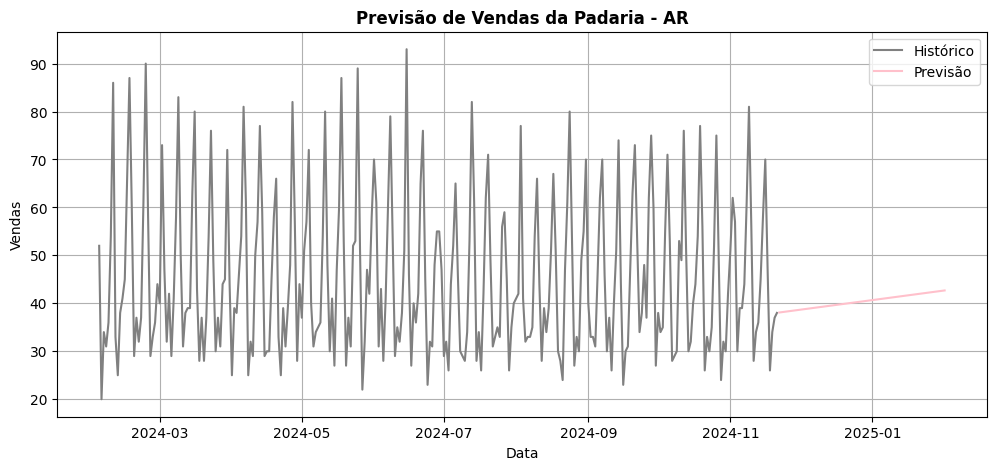

In [1517]:
plt.figure(figsize=(12, 5))
plt.plot(treino, label="Histórico", color="Gray")
plt.plot(previsao_ar, label="Previsão", color="Pink")

plt.title(
    "Previsão de Vendas da Padaria - AR",
    fontweight="bold"
)

plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid()
plt.show()

####**19.3 Comparação**

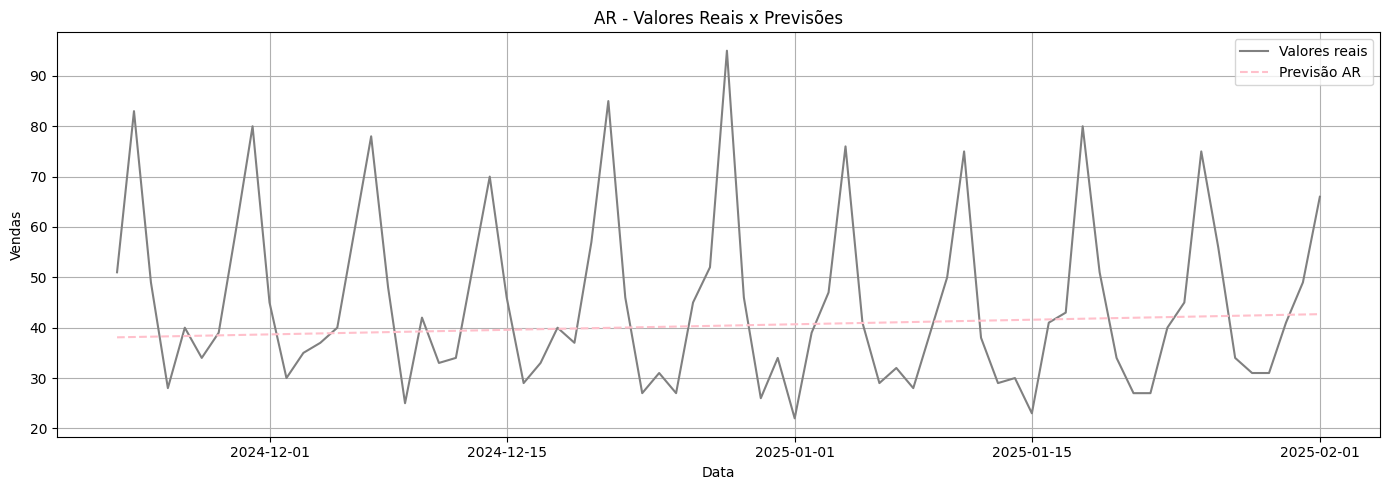

In [1518]:
plt.figure(figsize=(14, 5))

plt.plot(
    teste.index,
    teste.values,
    label="Valores reais",
    color="Gray"
)

plt.plot(
    previsao_ar.index,
    previsao_ar.values,
    label="Previsão AR",
    linestyle="--",
    color="Pink"
)

plt.title("AR - Valores Reais x Previsões")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####**19.4 Métricas**

In [1519]:
y_real = teste.values
y_pred = previsao_ar.values

# MAE
mae_ar = mean_absolute_error(y_real, y_pred)

# MSE
mse_ar = mean_squared_error(y_real, y_pred)

# RMSE
rmse_ar = np.sqrt(mse_ar)

# MAPE
mape_ar = np.mean(
    np.abs((y_real - y_pred) / y_real)
) * 100

# sMAPE
smape_ar = np.mean(
    2 * np.abs(y_real - y_pred) /
    (np.abs(y_real) + np.abs(y_pred))
) * 100

print(f"MAE:   {mae_ar:.4f}")
print(f"MSE:   {mse_ar:.4f}")
print(f"RMSE:  {rmse_ar:.4f}")
print(f"MAPE:  {mape_ar:.2f}%")
print(f"sMAPE: {smape_ar:.2f}%")

MAE:   12.8380
MSE:   313.9263
RMSE:  17.7180
MAPE:  27.68%
sMAPE: 28.01%


##**20. MA — Moving Average**
Utiliza os erros de previsão passados

####**20.1 Criação do Modelo**

In [1520]:
'''
p = 1 → componente AR
d = 0 → porque já diferenciamos a série
q = 1 → componente MA
'''

from statsmodels.tsa.arima.model import ARIMA
modelo_ma = ARIMA(
    treino_dif,
    order=(0, 0, 1)
).fit()

print('\n',modelo_ma.summary(),'\n')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



                                SARIMAX Results                                
Dep. Variable:                 Vendas   No. Observations:                  291
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1252.421
Date:                Tue, 08 Sep 2026   AIC                           2510.841
Time:                        22:54:56   BIC                           2521.861
Sample:                    02-05-2024   HQIC                          2515.256
                         - 11-21-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0483      1.208     -0.040      0.968      -2.416       2.319
ma.L1          0.0571      0.053      1.080      0.280      -0.047       0.161
sigma2       320.6800     33.671      9.524      0

####**20.2 Teste de Ljung Box**

In [1521]:
residuos_ma_dif = modelo_ma.resid

# Teste de Ljung-Box
ljung_box_ma = acorr_ljungbox(
    residuos_ma_dif,
    lags=[10],
    return_df=True
)

print(ljung_box_ma)

# Condicional para interpretação
p_valor_ma = ljung_box_ma['lb_pvalue'].iloc[0]

if p_valor_ma > 0.05:
    print("\nConclusão: não rejeitamos H0.")
    print("Os resíduos não apresentam autocorrelação significativa.")
    print("O modelo MA apresenta resíduos semelhantes a ruído branco.")
else:
    print("\nConclusão: rejeitamos H0.")
    print("Os resíduos apresentam autocorrelação significativa.")
    print("O modelo MA ainda possui informação não explicada.")

       lb_stat     lb_pvalue
10  293.937178  2.971254e-57

Conclusão: rejeitamos H0.
Os resíduos apresentam autocorrelação significativa.
O modelo MA ainda possui informação não explicada.


####**20.3 Previsão**

In [1522]:
previsao_ma_dif = modelo_ma.forecast(steps=len(teste))
ultimo_valor_treino = treino.iloc[-1]

previsao_ma = ultimo_valor_treino + previsao_ma_dif.cumsum()
previsao_ma.index = teste.index

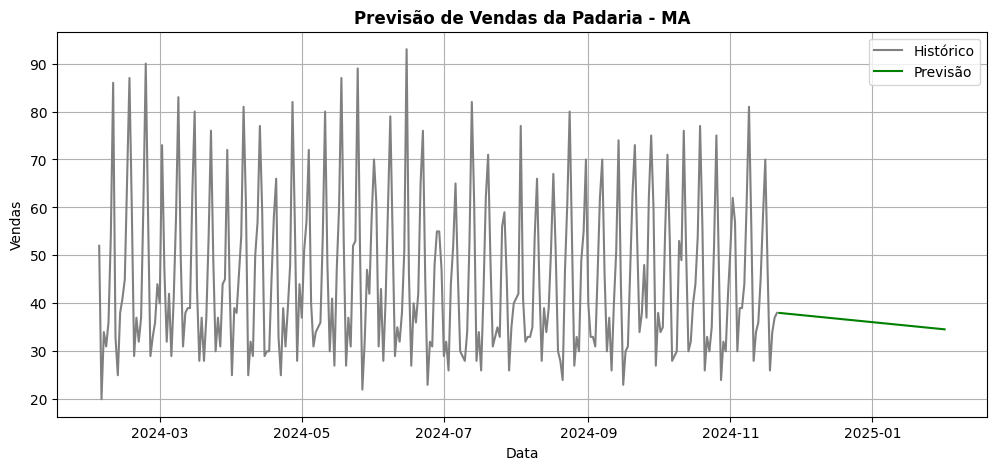

In [1523]:
plt.figure(figsize=(12, 5))
plt.plot(treino, label="Histórico", color="Gray")
plt.plot(previsao_ma, label="Previsão", color="Green")

plt.title(
    "Previsão de Vendas da Padaria - MA",
    fontweight="bold"
)

plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid()
plt.show()

####**20.4 Métricas**

In [1524]:
mae_ma = mean_absolute_error(teste, previsao_ma)
mse_ma = mean_squared_error(teste, previsao_ma)
rmse_ma = np.sqrt(mse_ma)

mape_ma = np.mean(
    np.abs((teste - previsao_ma) / teste)
) * 100

smape_ma = np.mean(
    2 * np.abs(teste - previsao_ma) /
    (np.abs(teste) + np.abs(previsao_ma))
) * 100

# MASE
mae_naive_treino = np.mean(
    np.abs(
        treino.iloc[1:].values -
        treino.iloc[:-1].values
    )
)

mase_ma = mae_ma / mae_naive_treino

print("=== MODELO MA ===")
print(f"MAE:   {mae_ma:.4f}")
print(f"MSE:   {mse_ma:.4f}")
print(f"RMSE:  {rmse_ma:.4f}")
print(f"MAPE:  {mape_ma:.2f}%")
print(f"sMAPE: {smape_ma:.2f}%")
print(f"MASE:  {mase_ma:.4f}")


=== MODELO MA ===
MAE:   13.2112
MSE:   357.9605
RMSE:  18.9198
MAPE:  25.82%
sMAPE: 28.88%
MASE:  0.8982


##**21. ARMA**

####**21.1 Criação do Modelo**

In [1525]:
modelo_arma = ARIMA(
    treino_dif,
    order=(1, 0, 1)
).fit()

print('\n',modelo_arma.summary(),'\n')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



                                SARIMAX Results                                
Dep. Variable:                 Vendas   No. Observations:                  291
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1201.341
Date:                Tue, 08 Sep 2026   AIC                           2410.682
Time:                        22:54:57   BIC                           2425.375
Sample:                    02-05-2024   HQIC                          2416.568
                         - 11-21-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0059      0.020     -0.291      0.771      -0.046       0.034
ar.L1          0.3856      0.073      5.266      0.000       0.242       0.529
ma.L1         -1.0000     15.451     -0.065      0

####**21.2 Previsão**

In [1526]:
# Previsão da série diferenciada
previsao_arma_dif = modelo_arma.predict(
    start=len(treino_dif),
    end=len(treino_dif) + len(teste) - 1,
    dynamic=False
)

# Voltar para a escala original
ultimo_valor_treino = treino.iloc[-1]

previsao_arma = (
    ultimo_valor_treino +
    previsao_arma_dif.cumsum()
)

# Ajustar o índice para o período de teste
previsao_arma.index = teste.index

print(previsao_arma.head())

Data
2024-11-22    42.055601
2024-11-23    43.615664
2024-11-24    44.213543
2024-11-25    44.440443
2024-11-26    44.524307
Name: predicted_mean, dtype: float64


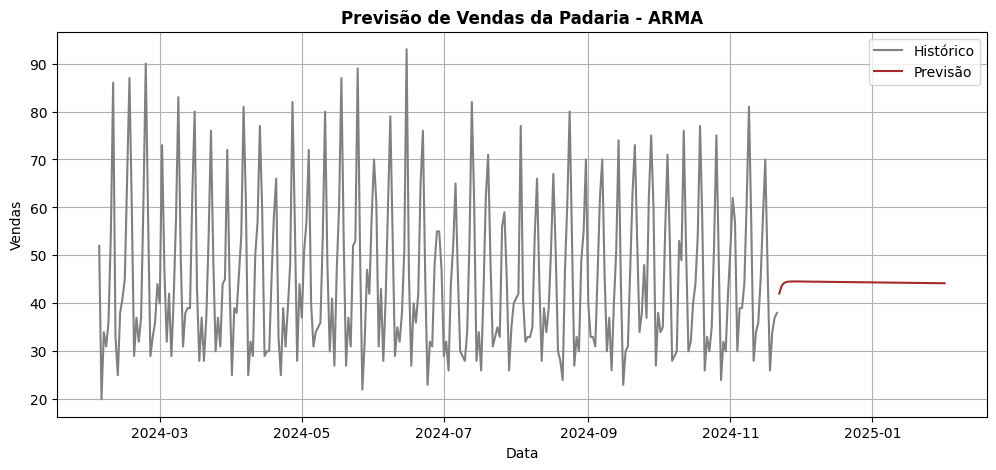

In [1527]:
plt.figure(figsize=(12, 5))
plt.plot(treino, label="Histórico", color="Gray")
plt.plot(previsao_arma, label="Previsão", color="Brown")

plt.title(
    "Previsão de Vendas da Padaria - ARMA",
    fontweight="bold"
)

plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid()
plt.show()

####**21.3 Comparação**

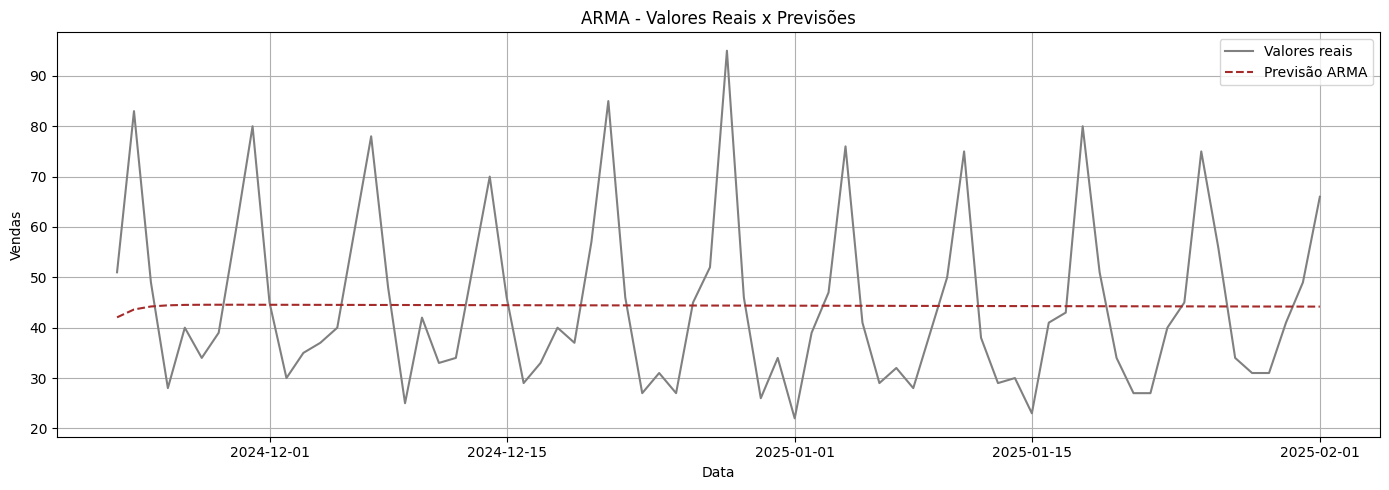

In [1528]:
plt.figure(figsize=(14, 5))

plt.plot(teste.index, teste.values, label="Valores reais", color="Gray")
plt.plot(
    previsao_arma.index,
    previsao_arma.values,
    label="Previsão ARMA",
    linestyle="--",
    color="Brown"
)

plt.title("ARMA - Valores Reais x Previsões")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

####**21.4 Métricas**

In [1529]:
y_real = teste.values
y_pred = previsao_arma.values

mae_arma = mean_absolute_error(y_real, y_pred)
mse_arma = mean_squared_error(y_real, y_pred)
rmse_arma = np.sqrt(mse_arma)

mape_arma = np.mean(
    np.abs((y_real - y_pred) / y_real)
) * 100

smape_arma = np.mean(
    2 * np.abs(y_real - y_pred) /
    (np.abs(y_real) + np.abs(y_pred))
) * 100

print("=== MODELO MA ===")
print(f"MAE:   {mae_arma:.4f}")
print(f"MSE:   {mse_arma:.4f}")
print(f"RMSE:  {rmse_arma:.4f}")
print(f"MAPE:  {mape_arma:.2f}%")
print(f"sMAPE: {smape_arma:.2f}%")

=== MODELO MA ===
MAE:   13.2173
MSE:   291.0749
RMSE:  17.0609
MAPE:  31.22%
sMAPE: 28.91%


##**22. Comparação Final**

####**22.1 Criação da Função**

In [1530]:
def calcular_mase(y_real, y_pred, y_treino):
    mae_modelo = mean_absolute_error(y_real, y_pred)

    mae_naive_treino = np.mean(
        np.abs(y_treino[1:] - y_treino[:-1])
    )

    mase = mae_modelo / mae_naive_treino

    return mase

####**22.2 Declaração das Variáveis**

In [1531]:
# Dados reais
y_real = teste.values
y_treino = treino.values

# MASE de cada modelo
mase_naive = calcular_mase(y_real, previsao_naive.values, y_treino)
mase_arima = calcular_mase(y_real, previsao_arima.values, y_treino)
mase_sarima = calcular_mase(y_real, previsao_sarima.values, y_treino)
mase_prophet = calcular_mase(y_real, previsao_prophet_series.values, y_treino)
mase_autoarima = calcular_mase(y_real, previsao_auto_arima.values, y_treino)
mase_ar = calcular_mase(y_real, previsao_ar.values, y_treino)
mase_ma = calcular_mase(y_real, previsao_ma.values, y_treino)
mase_arma = calcular_mase(y_real, previsao_arma.values, y_treino)

####**22.3 Criação de DataFrame**

In [1532]:
resultados = pd.DataFrame({
    "Modelo": [
        "Naive",
        "ARIMA",
        "SARIMA",
        "Prophet",
        "Auto ARIMA",
        "AR",
        "MA",
        "ARMA"
    ],

    "MAE": [
        mae_naive,
        mae_arima,
        mae_sarima,
        mae_prophet,
        mae_autoarima,
        mae_ar,
        mae_ma,
        mae_arma
    ],

    "MSE": [
        mse_naive,
        mse_arima,
        mse_sarima,
        mse_prophet,
        mse_autoarima,
        mse_ar,
        mse_ma,
        mse_arma
    ],

    "RMSE": [
        rmse_naive,
        rmse_arima,
        rmse_sarima,
        rmse_prophet,
        rmse_autoarima,
        rmse_ar,
        rmse_ma,
        rmse_arma
    ],

    "MAPE": [
        mape_naive,
        mape_arima,
        mape_sarima,
        mape_prophet,
        mape_autoarima,
        mape_ar,
        mape_ma,
        mape_arma
    ],

    "sMAPE": [
        smape_naive,
        smape_arima,
        smape_sarima,
        smape_prophet,
        smape_autoarima,
        smape_ar,
        smape_ma,
        smape_arma
    ],

    "MASE": [
        mase_naive,
        mase_arima,
        mase_sarima,
        mase_prophet,
        mase_autoarima,
        mase_ar,
        mase_ma,
        mase_arma
    ]
})

resultados

,Modelo,MAE,MSE,RMSE,MAPE,sMAPE,MASE
0,Naive,12.916667,334.222222,18.281746,26.237856,28.164252,0.878213
1,ARIMA,13.451913,292.070395,17.090067,32.500622,29.414703,0.914604
2,SARIMA,4.695495,36.040808,6.003400,11.435972,10.790676,0.319250
3,Prophet,4.574384,33.686150,5.803977,11.345320,10.675873,0.311015
4,Auto ARIMA,4.990201,40.890949,6.394603,12.050156,11.317941,0.339287
5,AR,12.837997,313.926274,17.717965,27.675360,28.005923,0.872864
6,MA,13.211246,357.960506,18.919844,25.815331,28.879832,0.898241
7,ARMA,13.217300,291.074923,17.060918,31.217888,28.908723,0.898653


####**22.4 Melhor Visão da Tabela**

In [1533]:
resultados_formatados = resultados.copy()

resultados_formatados["MAE"] = resultados_formatados["MAE"].round(4)
resultados_formatados["MSE"] = resultados_formatados["MSE"].round(4)
resultados_formatados["RMSE"] = resultados_formatados["RMSE"].round(4)
resultados_formatados["MAPE"] = resultados_formatados["MAPE"].round(2)
resultados_formatados["sMAPE"] = resultados_formatados["sMAPE"].round(2)
resultados_formatados["MASE"] = resultados_formatados["MASE"].round(4)

resultados_formatados

,Modelo,MAE,MSE,RMSE,MAPE,sMAPE,MASE
0,Naive,12.9167,334.2222,18.2817,26.24,28.16,0.8782
1,ARIMA,13.4519,292.0704,17.0901,32.50,29.41,0.9146
2,SARIMA,4.6955,36.0408,6.0034,11.44,10.79,0.3192
3,Prophet,4.5744,33.6862,5.8040,11.35,10.68,0.3110
4,Auto ARIMA,4.9902,40.8909,6.3946,12.05,11.32,0.3393
5,AR,12.8380,313.9263,17.7180,27.68,28.01,0.8729
6,MA,13.2112,357.9605,18.9198,25.82,28.88,0.8982
7,ARMA,13.2173,291.0749,17.0609,31.22,28.91,0.8987


####**22.5 Comparação dos modelos**

Para comparar o desempenho dos modelos, foram utilizadas as métricas MAE, MSE, RMSE, MAPE, sMAPE e MASE. Como essas métricas possuem diferentes interpretações, a avaliação foi realizada considerando conjuntamente seus resultados.

O **MAE (Mean Absolute Error)** representa o erro absoluto médio das previsões. Quanto menor o valor, mais próximas as previsões estão dos valores observados.

O **MSE (Mean Squared Error)** calcula a média dos erros ao quadrado, atribuindo maior peso aos erros de maior magnitude. Portanto, valores menores indicam melhor desempenho, especialmente quando se deseja penalizar grandes erros.

O **RMSE (Root Mean Squared Error)** corresponde à raiz quadrada do MSE e possui a mesma unidade da variável analisada. Assim como o MSE, valores menores indicam melhor desempenho e essa métrica é particularmente sensível a erros elevados.

O **MAPE (Mean Absolute Percentage Error)** representa o erro percentual médio absoluto. Valores menores indicam maior precisão das previsões. Entretanto, essa métrica deve ser interpretada com cautela quando existem valores observados próximos de zero.

O **sMAPE (Symmetric Mean Absolute Percentage Error)** também representa o erro percentual, porém utiliza uma formulação simétrica entre os valores observados e previstos. Assim como o MAPE, quanto menor o valor, melhor o desempenho.

Por fim, o **MASE (Mean Absolute Scaled Error)** permite comparar o erro do modelo com o erro de uma previsão Naive realizada dentro do conjunto de treinamento. Valores de MASE inferiores a 1 indicam que o modelo apresentou erro inferior ao benchmark Naive, enquanto valores superiores a 1 indicariam desempenho inferior ao benchmark.

De forma geral, observa-se que os modelos **SARIMA, Prophet e AutoARIMA** apresentaram desempenho significativamente superior ao Naive nas principais métricas de erro. Já os modelos AR, MA e ARMA aplicados à série diferenciada apresentaram resultados próximos ou inferiores ao desempenho dos modelos ajustados diretamente à série original.

Entre os modelos avaliados, o **Prophet apresentou os menores valores de MAE, RMSE, MAPE e sMAPE**, além de apresentar o menor MASE entre os modelos considerados. O SARIMA apresentou desempenho bastante próximo, enquanto o AutoARIMA também apresentou desempenho competitivo.

Dessa forma, considerando conjuntamente as métricas calculadas no conjunto de teste, o **Prophet apresenta-se como o modelo de melhor desempenho preditivo para esta série**, sendo selecionado para a etapa final de previsão.


In [1534]:
# Ranking pelo MAE
ranking_mae = resultados.sort_values("MAE").reset_index(drop=True)
ranking_mae["Posição"] = range(1, len(ranking_mae) + 1)

ranking_mae[
    ["Posição", "Modelo", "MAE", "RMSE", "MAPE", "sMAPE", "MASE"]
]

,Posição,Modelo,MAE,RMSE,MAPE,sMAPE,MASE
0,1,Prophet,4.574384,5.803977,11.345320,10.675873,0.311015
1,2,SARIMA,4.695495,6.003400,11.435972,10.790676,0.319250
2,3,Auto ARIMA,4.990201,6.394603,12.050156,11.317941,0.339287
3,4,AR,12.837997,17.717965,27.675360,28.005923,0.872864
4,5,Naive,12.916667,18.281746,26.237856,28.164252,0.878213
5,6,MA,13.211246,18.919844,25.815331,28.879832,0.898241
6,7,ARMA,13.217300,17.060918,31.217888,28.908723,0.898653
7,8,ARIMA,13.451913,17.090067,32.500622,29.414703,0.914604
